# Get final formatted counts for RNA-seq that match up to Nanostring Genes
I will consider TPM, RPKM, DESeq2, and CPM based normalization. I will consider RNA-seq based isoforms and NanoString inspired exons or isoforms.

Author: Hope A. Townsend

In [2]:
library(data.table)
library(stringr)
library(DESeq2)
library(here)
library(dplyr)
library(tidyr)

## Read in the original counts (unharmonized)

In [3]:
# Adzib
rnaseq_gene <- fread(here("../RNASeq//Adzib/counts//Adzibolosu_str_gtf_genes.txt"))
rnaseq_gene[1:2,]
rnaseq <- fread(here("../RNASeq//Adzib/counts/Adzibolosu_str_gtf_transcripts.txt"))
rnaseq[1:2,]
dim(rnaseq_gene)
dim(rnaseq)

# Javella
rnaseq_gene_jav = as.data.frame(fread(here("../Microarray/Javello_TS5_RPKM.csv"), sep=","))
rnaseq_gene_jav$Patient <- paste0("PJ_", rnaseq_gene_jav[["Patient ID"]])
rnaseq_gene_jav[1:4,]
unique(rnaseq_gene_jav$V7)
unique(rnaseq_gene_jav$Patient)
# make it easier to edit later
colnames(rnaseq_gene_jav) <- c("PatientID", "Ensembl_gene", "Geneid", "GFOLD", "Pre_RPKM", "Post_RPKM", "V7", "Patient")


# EGA
rnaseq_gene_ega <- fread(here("../RNASeq/EGA/counts//EGA_str_gtf_genes.txt"))
rnaseq_gene_ega[1:2,]
rnaseq_ega <- fread(here("../RNASeq/EGA/counts/EGA_str_gtf_transcripts.txt"))
rnaseq_ega[1:2,]
dim(rnaseq_gene_ega)
dim(rnaseq_ega)

## MicroArray (SST-RMA normalization --> quantile normalized and log2 transformed)
jim_counts <- fread("../../../Microarray/data/JimSanchez_normcounts_fromGEO_fixednames_09.12.24.txt")
jim_counts[1:2,]

Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,38,91,52,73,...,123,56,45,53,62,73,32,62,47,58


Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NR_046018.2,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
NR_024540.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,38,91,52,73,...,123,56,45,53,62,73,32,62,47,58


[1] 49771    54

[1] 200121     54

,Patient ID,Ensembl gene,Gene name,GFOLD,Pre-chemotherapy RPKM,Post-chemotherapy RPKM,V7,Patient
,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
1,1,ENSG00000121410,A1BG,-0.171681,1.864210,1.236680,NA,PJ_1
2,2,ENSG00000121410,A1BG,0.000000,0.713873,0.923893,NA,PJ_2
3,5,ENSG00000121410,A1BG,0.947737,0.513896,1.236450,NA,PJ_5
4,6,ENSG00000121410,A1BG,-0.132308,0.596550,0.372954,NA,PJ_6


...

Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,5,10,2,...,0,1,0,1,5,3,3,4,5,3
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,17,324,295,126,...,6,16,14,11,22,44,169,251,532,338


Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NR_046018.2,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,5,10,2,...,0,1,0,1,5,3,3,4,5,3
NR_024540.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,17,324,295,126,...,6,16,14,11,22,44,169,251,532,338


[1] 49771   122

[1] 200121    122

Geneid,NAC1_Pre,NAC1_Post,NAC3_Pre,NAC3_Post,NAC4_Pre,NAC4_Post,NAC5_Pre,NAC5_Post,NAC37_Pre,...,NAC34_Pre,NAC34_Post,NAC32_Pre,NAC32_Post,NAC23_Pre,NAC23_Post,NAC39_Pre,NAC39_Post,Gene,Fixed_Gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
DDX11L1:NR_046018,3.09277,3.18622,3.00086,2.85168,2.95304,3.20436,3.05245,3.00032,3.06271,...,3.31583,3.71156,3.35123,3.16834,3.16300,3.15237,2.85486,3.08086,DDX11L1,DDX11L1
MIR1302-10:NR_036267,5.11765,5.23930,5.45755,5.67886,5.07335,5.16876,5.14388,4.58668,5.29751,...,5.02839,5.32867,4.82798,5.07185,4.72327,4.90700,5.27394,4.88376,MIR1302-10,MIR1302-10


In [4]:
# get the javella in the same format as Adzib (Geneid and Patient RPKMs pre and post)
# add length to it

rnaseq_gene_rpkm_jav <- rnaseq_gene_jav %>%
  pivot_longer(cols = c(Pre_RPKM, Post_RPKM),
               names_to = "Timepoint",
               values_to = "RPKM") %>%
  # Create a new column combining Patient and Timepoint
  mutate(Patient_Time = sub("_RPKM", "", paste(Patient, Timepoint, sep = "_"))) %>%
  select(Geneid, Patient_Time, RPKM) %>%
  pivot_wider(names_from = Patient_Time, values_from = RPKM) 

# View the result
head(rnaseq_gene_rpkm_jav)
dim(rnaseq_gene_rpkm_jav)

Geneid,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.8642100,1.236680,0.7138730,0.9238930,0.5138960,1.2364500,0.5965500,0.3729540,1.590190,...,1.0921500,0.9240750,0.9836820,0.4426100,2.0126200,0.8519200,1.4459400,0.9367800,0.9444650,0.8087880
A1CF,0.0104808,0.056426,0.0163626,0.0158933,0.0265894,0.0165624,0.0106653,0.0577158,0.115723,...,0.0215376,0.0367132,0.0597867,0.0519299,0.0243088,0.0162463,0.0000000,0.0115504,0.0653631,0.0610363
A2M,30.1154000,86.226600,25.2580000,68.7988000,62.1897000,87.5393000,21.7785000,25.8717000,10.902900,...,22.6458000,63.5309000,109.0640000,46.1092000,49.9351000,46.7991000,16.3807000,28.8561000,41.1993000,101.0300000
A2ML1,1.6708900,0.373196,0.1888380,0.1146380,1.3224500,0.8096570,1.0233300,2.6367300,0.115924,...,7.7413900,3.7049000,0.1604620,0.1355030,0.1631060,0.1880400,1.0359100,0.5476690,0.2923800,0.2479980
A3GALT2,0.3148310,0.283755,0.0000000,0.2797350,1.0139900,0.7773630,0.0500583,0.7537870,0.443700,...,1.9128900,0.9649650,0.2295910,0.4874710,0.2808480,0.2668850,0.0337037,0.1807080,1.1078300,0.6366150
A4GALT,1.4386800,4.950410,8.6660400,7.3232400,1.5920600,8.3496000,2.6128400,1.8873400,1.650020,...,2.3073300,2.0158100,2.9298800,1.7243200,2.3100900,1.8467900,1.4682800,1.4313500,1.5005600,4.0388400


[1] 19995    41

In [6]:
# Get the isoforms used by Nanostring
nano <- fread(here("data/Matched//Norm_counts_3.24.25.txt"))
nano[1:2,]

Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,20250320_30103031210726-01_S13-9885 J1_01.RCC,20250320_30103031210726-01_S14-12409 D2_05.RCC,20250320_30103031210726-01_S14-2474 B2_04.RCC,20250320_30103031210726-01_S16-23867 D1_06.RCC,20250320_30103031210726-01_S16-7066 C1_07.RCC,20250320_30103031210726-01_S17-18143 A2_08.RCC,20250320_30103031210726-01_S21-24801 A2_11.RCC,20250320_30103031210726-01_S21-28943 A10_10.RCC,20250320_30103031210726-01_S21-32280 A2_09.RCC,20250320_30103031210726-01_S22-9274 B7_12.RCC
<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


In [7]:
nonano_adzib = setdiff(nano[["Probe Name"]], rnaseq_gene$Geneid)
length(nonano_adzib)
nonano_adzib
nonano_jav = setdiff(nano[["Probe Name"]], rnaseq_gene_rpkm_jav$Geneid)
length(nonano_jav)
nonano_jav
nonano_ega = setdiff(nano[["Probe Name"]], rnaseq_gene_ega$Geneid)
length(nonano_ega)
nonano_ega
nonano_jim = setdiff(nano[["Probe Name"]], jim_counts$Fixed_Gene)
length(nonano_jim)
nonano_jim

cat("\nOnly no immediate connection in Jav:", setdiff(nonano_jav, nonano_adzib))
cat("\nOnly no immediate connection in Adzib:", setdiff(nonano_adzib, nonano_jav))
cat("\nNo immediate connection in both:", intersect(nonano_adzib, nonano_jav))

[1] 28

[1] "CCL3/L1"   "CD45RA"    "CD45RB"    "CD45RO"    "CLECL1"    "CXorf36"  
 [7] "FCGR3A/B"  "H2AFX"     "MAGEA3/A6" "MB21D1"    "TMEM173"   "TPSAB1/B2"
[13] "TTC30A"    "XCL1/2"    "NEG_A"     "NEG_B"     "NEG_C"     "NEG_D"    
[19] "NEG_E"     "NEG_F"     "NEG_G"     "NEG_H"     "POS_A"     "POS_B"    
[25] "POS_C"     "POS_D"     "POS_E"     "POS_F"

[1] 28

[1] "CCL3/L1"   "CD45RA"    "CD45RB"    "CD45RO"    "CXorf36"   "FAM30A"   
 [7] "FCGR3A/B"  "LILRA3"    "MAGEA3/A6" "MB21D1"    "TCL1A"     "TGFB1"    
[13] "TPSAB1/B2" "XCL1/2"    "NEG_A"     "NEG_B"     "NEG_C"     "NEG_D"    
[19] "NEG_E"     "NEG_F"     "NEG_G"     "NEG_H"     "POS_A"     "POS_B"    
[25] "POS_C"     "POS_D"     "POS_E"     "POS_F"

[1] 28

[1] "CCL3/L1"   "CD45RA"    "CD45RB"    "CD45RO"    "CLECL1"    "CXorf36"  
 [7] "FCGR3A/B"  "H2AFX"     "MAGEA3/A6" "MB21D1"    "TMEM173"   "TPSAB1/B2"
[13] "TTC30A"    "XCL1/2"    "NEG_A"     "NEG_B"     "NEG_C"     "NEG_D"    
[19] "NEG_E"     "NEG_F"     "NEG_G"     "NEG_H"     "POS_A"     "POS_B"    
[25] "POS_C"     "POS_D"     "POS_E"     "POS_F"

[1] 32

[1] "CCL4"     "CD45RA"   "CD45RB"   "CD45RO"   "ERBB2"    "FCAR"    
 [7] "HLA-B"    "HLA-DMB"  "HLA-DQA1" "ITGA1"    "KIR3DL1"  "KIR3DL2" 
[13] "KLRK1"    "LILRA3"   "NCR1"     "SIGLEC5"  "TNF"      "ABCF1"   
[19] "NEG_A"    "NEG_B"    "NEG_C"    "NEG_D"    "NEG_E"    "NEG_F"   
[25] "NEG_G"    "NEG_H"    "POS_A"    "POS_B"    "POS_C"    "POS_D"   
[31] "POS_E"    "POS_F"


Only no immediate connection in Jav: FAM30A LILRA3 TCL1A TGFB1
Only no immediate connection in Adzib: CLECL1 H2AFX TMEM173 TTC30A
No immediate connection in both: CCL3/L1 CD45RA CD45RB CD45RO CXorf36 FCGR3A/B MAGEA3/A6 MB21D1 TPSAB1/B2 XCL1/2 NEG_A NEG_B NEG_C NEG_D NEG_E NEG_F NEG_G NEG_H POS_A POS_B POS_C POS_D POS_E POS_F

### Filter raw RNAseq counts based on median TPM > 1
In TPM, we normalize the gene counts by length first and then a scaling factor. Therefore, the sum of TPMs in each sample are the same -- easier to compare proportion of reads with samples. E.g. TPM for gene A in Sample 1 is 3.33 and 2 is 3.33 means the exact same proportion of total reads mapped to genes in each sample. 

I will not filter for WGNCA analysis since some genes not well-expressed here might be well expressed in my other data.

In [8]:
library(data.table)

calculate_rpkm <- function(gene_dt, trans_dt, length_col = "Length", gene_col = "Geneid") {
    " Caclulates the size factors based on the GENES rather than transcripts to ensure no overlapping counts"
    trans_dt <- as.data.table(trans_dt)
    gene_dt <- as.data.table(gene_dt)

  # Identify sample (count) columns
  sample_cols <- setdiff(names(gene_dt), c(gene_col, length_col, "Chr", "Start", "End", "Strand"))

  # Initialize result data.table with gene ID of transcripts and genes
  rpkm_gene_dt <- gene_dt[, .(Geneid = get(gene_col))]
  rpkm_trans_dt <- trans_dt[, .(Geneid = get(gene_col))]

  # Calculate RPKM per sample and store columns
  for (sample in sample_cols) {
    scale_factor <- sum(gene_dt[[sample]]) 
    rpm_gene <- gene_dt[[sample]] / scale_factor * 1e6
    rpm_trans <- trans_dt[[sample]] / scale_factor * 1e6
    rpkm_gene <-  rpm_gene / (gene_dt[[length_col]] / 1000)
    rpkm_gene_dt[, (paste0(sample, "_RPKM")) := rpkm_gene]
    rpkm_trans <-  rpm_trans / (trans_dt[[length_col]] / 1000)
    rpkm_trans_dt[, (paste0(sample, "_RPKM")) := rpkm_trans]
  }

  # Calculate median RPKM across samples (vectorized)
  rpkm_cols <- grep("_RPKM$", names(rpkm_gene_dt), value = TRUE)
  rpkm_gene_dt[, Median_RPKM := apply(.SD, 1, median), .SDcols = rpkm_cols]
  rpkm_cols <- grep("_RPKM$", names(rpkm_trans_dt), value = TRUE)
  rpkm_trans_dt[, Median_RPKM := apply(.SD, 1, median), .SDcols = rpkm_cols]

  return(list("G"=rpkm_gene_dt, "T"=rpkm_trans_dt))
}

calculate_tpm <- function(gene_dt, trans_dt, length_col = "Length", gene_col = "Geneid") {
  trans_dt <- as.data.table(trans_dt)
  gene_dt <- as.data.table(gene_dt)

  # Identify sample (count) columns
  sample_cols <- setdiff(names(gene_dt), c(gene_col, length_col, "Chr", "Start", "End", "Strand"))

  # Initialize result data.table with gene ID
  tpm_gene_dt <- gene_dt[, .(Geneid = get(gene_col))]
  tpm_trans_dt <- trans_dt[, .(Geneid = get(gene_col))]

  # Calculate TPM per sample and store columns
  for (sample in sample_cols) {
    # calculate the scale factor based on the genes rather than transcripts
    rpk_gene <- gene_dt[[sample]] / (gene_dt[[length_col]] / 1000)
    rpk_trans <- trans_dt[[sample]] / (trans_dt[[length_col]] / 1000)
    scale_factor <- sum(rpk_gene)
    tpm_gene <- rpk_gene / scale_factor * 1e6
    tpm_trans <- rpk_trans / scale_factor * 1e6
    tpm_gene_dt[, (paste0(sample, "_TPM")) := tpm_gene]
    tpm_trans_dt[, (paste0(sample, "_TPM")) := tpm_trans]
  }

  # Calculate median TPM across samples (vectorized)
  tpm_cols <- grep("_TPM$", names(tpm_gene_dt), value = TRUE)
  tpm_gene_dt[, Median_TPM := apply(.SD, 1, median), .SDcols = tpm_cols]
  tpm_cols <- grep("_TPM$", names(tpm_trans_dt), value = TRUE)
  tpm_trans_dt[, Median_TPM := apply(.SD, 1, median), .SDcols = tpm_cols]

  return(list("G"=tpm_gene_dt, "T"=tpm_trans_dt))
}


rpkm_list <- calculate_rpkm(rnaseq_gene, rnaseq)
rnaseq_rpkm = rpkm_list[["T"]]
rnaseq_gene_rpkm = rpkm_list[["G"]]

tpm_list <- calculate_tpm(rnaseq_gene, rnaseq)
rnaseq_tpm = tpm_list[["T"]]
rnaseq_gene_tpm = tpm_list[["G"]]
nrow(rnaseq_gene_tpm[rnaseq_gene_tpm$Median_TPM > 1,])


rpkm_list <- calculate_rpkm(rnaseq_gene_ega, rnaseq_ega)
rnaseq_ega_rpkm = rpkm_list[["T"]]
rnaseq_gene_ega_rpkm = rpkm_list[["G"]]

tpm_list <- calculate_tpm(rnaseq_gene_ega, rnaseq_ega)
rnaseq_ega_tpm = tpm_list[["T"]]
rnaseq_gene_ega_tpm= tpm_list[["G"]]
nrow(rnaseq_gene_ega_tpm[rnaseq_gene_ega_tpm$Median_TPM > 1,])


rnaseq_gene_filt = rnaseq_gene[rnaseq_gene$Geneid %in% rnaseq_gene_tpm[rnaseq_gene_tpm$Median_TPM > 1,]$Geneid,]
nrow(rnaseq_gene_filt)

rnaseq_gene_ega_filt = rnaseq_gene_ega[rnaseq_gene_ega$Geneid %in% rnaseq_gene_ega_tpm[rnaseq_gene_ega_tpm$Median_TPM > 1,]$Geneid,]
nrow(rnaseq_gene_ega_filt)

[1] 17848

[1] 17988

[1] 17848

[1] 17988

In [9]:
# Get genes to use for WGNCA based on what in previous
rnamatch_wgcna = fread(here("data/Matched/WGCNA_norm_RNAMatch_counts.txt"))
rnamatch_wgcna[1:2,]
rnaseq_gene_wgcna <- rnaseq_gene[rnaseq_gene$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_wgcna)
rnaseq_gene_ega_wgcna <- rnaseq_gene_ega[rnaseq_gene_ega$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_ega_wgcna)

# get the RPKM and TPM
rnaseq_gene_rpkm_jav_wgcna <- rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_rpkm_jav_wgcna)
rnaseq_gene_rpkm_wgcna <- rnaseq_gene_rpkm[rnaseq_gene_rpkm$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_rpkm_wgcna)
rnaseq_gene_ega_rpkm_wgcna <- rnaseq_gene_ega_rpkm[rnaseq_gene_ega_rpkm$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_ega_rpkm_wgcna)

rnaseq_gene_tpm_wgcna <- rnaseq_gene_tpm[rnaseq_gene_tpm$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_tpm_wgcna)
rnaseq_gene_ega_tpm_wgcna <- rnaseq_gene_ega_tpm[rnaseq_gene_ega_tpm$Geneid %in% rnamatch_wgcna$V1,]
nrow(rnaseq_gene_ega_tpm_wgcna)

Warning message in fread(here("data/Matched/WGCNA_norm_RNAMatch_counts.txt")):
"Se detectaron 26 nombres de columnas pero los datos tienen 27 columnas (es decir, un archivo no v'alido). Se agrega/n 1 nombre(s) predeterminado(s) adicional/es de columna para la primera columna que se supone que son nombres de filas o un 'indice. Utilice setnames() despu'es si esta suposici'on no es correcta, o corrija el comando de escritura de archivo que cre'o el archivo para crear un archivo v'alido."


V1,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_05_S22-010607B2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,...,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538,BB24_27_S22-003884
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,41.343847,61.624544,38.10107,38.467759,19.29865,45.168972,52.648659,50.37045,44.624473,...,39.80493,46.558858,39.44617,48.545452,51.661798,108.914818,29.324012,78.28242,43.2559,30.388590
MIR6859-1,4.493896,6.555803,0.00000,2.622802,0.00000,2.945803,1.120184,0.00000,1.749979,...,0.00000,5.431867,0.00000,2.427273,1.230043,5.445741,4.189145,0.00000,0.0000,2.681346


[1] 18021

[1] 18021

[1] 14831

[1] 18021

[1] 18021

[1] 18021

[1] 18021

## Get DESeq2-based normalized counts for RNAseq if raw counts are available

In [10]:
housekeeping_genes <- c(
  "ACTB", "GAPDH", "B2M", "RPLP0", "PGK1", "HPRT1", "TBP", "TUBB", "YWHAG", "TFRC",
  "HMBS", "EEF1A1", "PPIA", "RPS18", "ALDOA", "RPL13A", "RPL32", "RPL19", "RPS9", "SDHA",
  "LDHA", "ATP5B", "MDH1", "NADH5", "SNRPD3", "GUSB", "VCP", "PSMB4", "CYC1",
  "RPS8", "RPS13", "RPL11", "RPL23", "RPL27", "PSMB1", "PSMC2", "RPS11", "RPL10A", "RPS21",
  "RPS27A", "RPL14", "ATP5O", "CS", "ENO1", "RPS4X", "UQCRC2", "ATP6V1E1", "UCHL5",
  "VDAC1", "RPL6", "RPL7A", "RPS5", "RPL30", "TUBA1A", "TUBA1B", "TUBA4A", "RPS3", "RPS3A",
  "RPS7", "RPLP1", "UQCRB", "RPL12", "RPL13", "RPL28", "EEF2", "ATF6", "NDUFA1",
  "NDUFA2", "NDUFA4", "ATP5A1", "RPL26", "NDUFB5", "NDUFB8", "RPS15", "NDUFS2", "COX7A2",
  "CCT6A", "CCT8", "CCT3", "PSMA6", "RPL31", "RPL15", "RPS14", "RPL35A", "COX4I1", "RPL4",
  "NDUFV1", "NDUFV2", "UQCRFS1",  "RPS19", "RPS20",
  "TUBG1", "VAMP2", "VAMP3", "VDAC2", "ATP6V1A", "ATP6V1C1", "COX5A", "COX5B", "COX6B1",
  "COX6C", "CYCS", "ENO2", "FASN", "FH", "FTH1", "FUS", "GLS", "GPI", "GSK3B", "HADHA",
  "HDAC1", "HDAC2", "HDAC3",   "IDH3A", "IDH3B", "IGF1R",
  "IMPDH1", "KARS", "LDHB", "LMNB1",  "MTHFD1", "MYH9", "NDUFA9",
  "NDUFB3", "NDUFS1", "NDUFV3", "OAT", "PDHA1", "PPIB", "PRKACA", "PSMA5",
  "PSMB2", "PSMD1", "PSMD2", "PTMA", "RAN", "RELA", "RHOA", "RPL18A", "RPL21", "RPL22",
  "RPL29", "RPL34", "RPL37", "RPL38", "RPL5", "RPL9", "RPS16", "RPS17", "RPS23", "RPS24",
  "RPS25", "RPS26", "SDHB", "SRP9", "ST13", "STMN1", "SUCLG1", "TFAM", 
  "TKT", "TMED2", "TMEM97", "TPM1", "TUBA1C", "TUBB2B", "TXN", "TXNRD1", "UBC",
  "UBE2I", "UBE2N", "UCHL1", "VDAC3", "VIM", "VPS29", "VPS35", "XPO1", "YWHAE", "YWHAQ",
  "ZNF652", "ZNF654", "ABCF1", "DNAJC14", "ERCC3", "G6PD",  "NRDE2", "OAZ1", 
  "POLR2A", "PSMC4", "PUM1", "SF3A1", "STK11IP", "TBC1D10B", "TLK2", "TMUB2", "UBB"
)

length(housekeeping_genes)

[1] 196

In [11]:
# Get housekeeping only
rnaseq_hk = rnaseq_gene[rnaseq_gene$Geneid %in% housekeeping_genes,]
dim(rnaseq_hk)
rnaseq_ega_hk = rnaseq_gene_ega[rnaseq_gene_ega$Geneid %in% housekeeping_genes,]
dim(rnaseq_ega_hk)

# Get matrices
RNA_matrix <- as.matrix(rnaseq[, 7:(ncol(rnaseq))])
rownames(RNA_matrix) <- rnaseq$Geneid
RNA_gene_matrix <- as.matrix(rnaseq_gene_wgcna[, 7:(ncol(rnaseq_gene_wgcna))])
rownames(RNA_gene_matrix) <- rnaseq_gene_wgcna$Geneid
RNA_gene_filt_matrix <- as.matrix(rnaseq_gene_filt[, 7:(ncol(rnaseq_gene_filt))])
rownames(RNA_gene_filt_matrix) <- rnaseq_gene_filt$Geneid
RNA_hk_matrix <- as.matrix(rnaseq_hk[, 7:(ncol(rnaseq_hk))])
rownames(RNA_hk_matrix) <- rnaseq_hk$Geneid

RNA_matrix_ega <- as.matrix(rnaseq_ega[, 7:(ncol(rnaseq_ega))])
rownames(RNA_matrix_ega) <- rnaseq_ega$Geneid
RNA_gene_matrix_ega <- as.matrix(rnaseq_gene_ega_wgcna[, 7:(ncol(rnaseq_gene_ega_wgcna))])
rownames(RNA_gene_matrix_ega) <- rnaseq_gene_ega_wgcna$Geneid
RNA_gene_filt_matrix_ega <- as.matrix(rnaseq_gene_ega_filt[, 7:(ncol(rnaseq_gene_ega_filt))])
rownames(RNA_gene_filt_matrix_ega) <- rnaseq_gene_ega_filt$Geneid
RNA_hk_matrix_ega <- as.matrix(rnaseq_ega_hk[, 7:(ncol(rnaseq_ega_hk))])
rownames(RNA_hk_matrix_ega) <- rnaseq_ega_hk$Geneid

[1] 191  54

[1] 191 122

In [12]:
dim(RNA_matrix_ega)
dim(RNA_gene_matrix_ega)
dim(RNA_gene_filt_matrix_ega)
dim(RNA_hk_matrix_ega)

[1] 200121    116

[1] 18021   116

[1] 17988   116

[1] 191 116

In [13]:
# ensure all matrices are in the same order for columns
RNA_matrix <- RNA_matrix[,colnames(RNA_hk_matrix)]
RNA_gene_matrix <- RNA_gene_matrix[,colnames(RNA_hk_matrix)]
RNA_gene_filt_matrix <- RNA_gene_filt_matrix[,colnames(RNA_hk_matrix)]

RNA_matrix_ega <- RNA_matrix_ega[,colnames(RNA_hk_matrix_ega)]
RNA_gene_matrix_ega <- RNA_gene_matrix_ega[,colnames(RNA_hk_matrix_ega)]
RNA_gene_filt_matrix_ega <- RNA_gene_filt_matrix_ega[,colnames(RNA_hk_matrix_ega)]

# create design for DESeq2
design <- data.table("Name"=as.factor(colnames(RNA_hk_matrix)))
design_ega <- data.table("Name"=as.factor(colnames(RNA_hk_matrix_ega)))


  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and

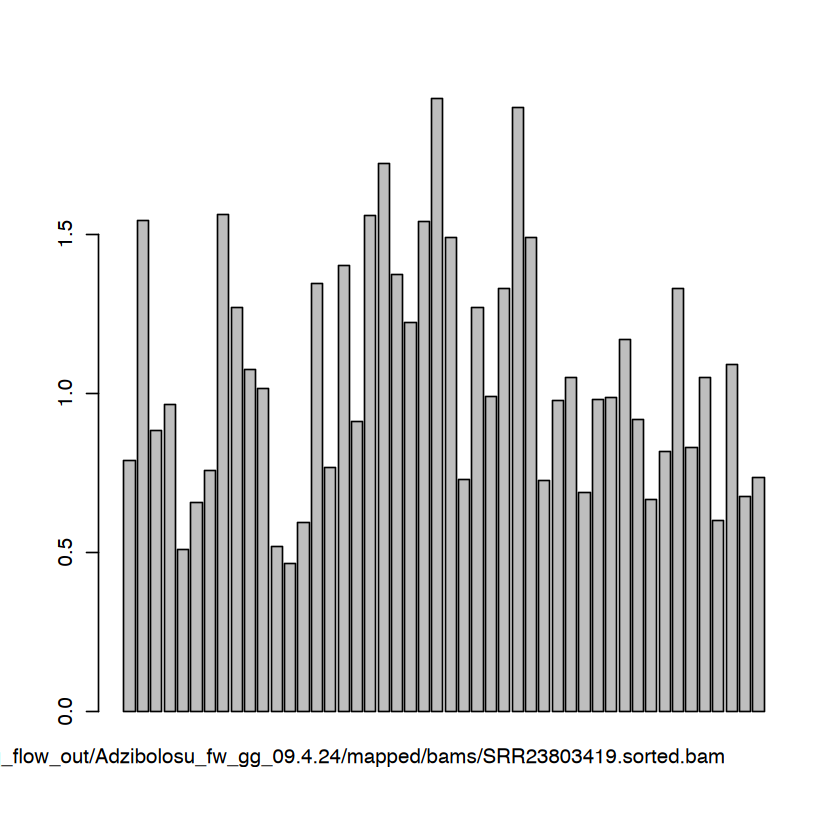

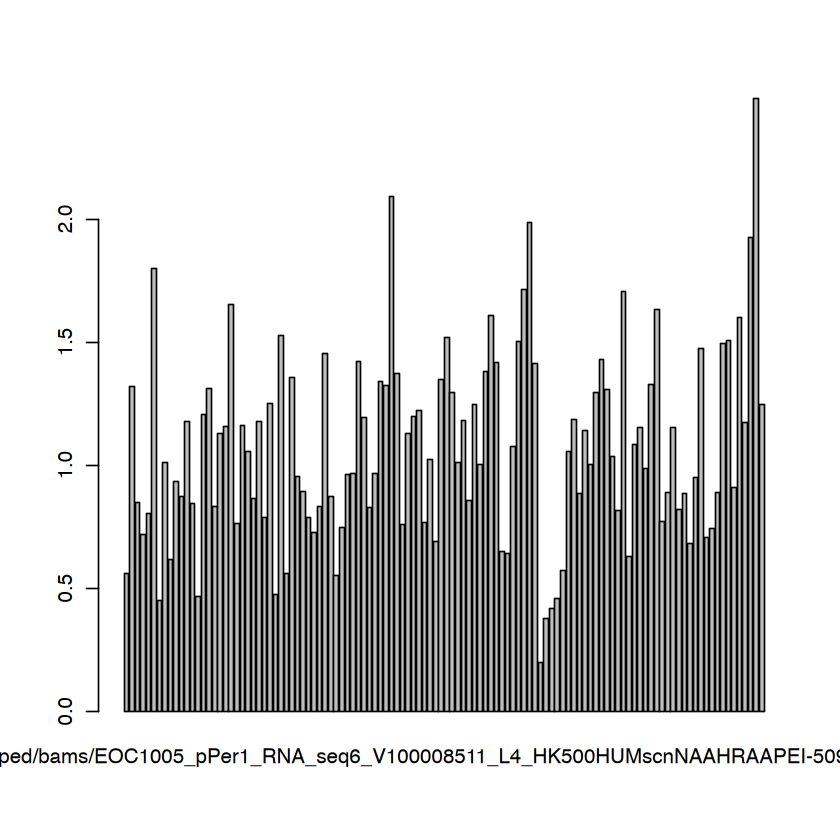

In [14]:
dds_hk <- DESeqDataSetFromMatrix(countData = RNA_hk_matrix, colData = design, 
                                    design = ~ Name)
dds_hk = estimateSizeFactors(dds_hk, type="ratio")

dds_trans <- DESeqDataSetFromMatrix(countData = RNA_matrix, colData = design, 
                                    design = ~ Name)
dds_gene <- DESeqDataSetFromMatrix(countData = RNA_gene_matrix, colData = design, 
                                    design = ~ Name)
dds_gene_filt <- DESeqDataSetFromMatrix(countData = RNA_gene_filt_matrix, colData = design, 
                                    design = ~ Name)

sizeFactors(dds_trans) = sizeFactors(dds_hk)
sizeFactors(dds_gene) = sizeFactors(dds_hk)
sizeFactors(dds_gene_filt) = sizeFactors(dds_hk)
barplot(sizeFactors(dds_hk))



dds_hk_ega <- DESeqDataSetFromMatrix(countData = RNA_hk_matrix_ega, colData = design_ega, 
                                    design = ~ Name)
dds_hk_ega = estimateSizeFactors(dds_hk_ega, type="ratio")

dds_trans_ega <- DESeqDataSetFromMatrix(countData = RNA_matrix_ega, colData = design_ega, 
                                    design = ~ Name)
dds_gene_ega <- DESeqDataSetFromMatrix(countData = RNA_gene_matrix_ega, colData = design_ega, 
                                    design = ~ Name)
dds_gene_filt_ega <- DESeqDataSetFromMatrix(countData = RNA_gene_filt_matrix_ega, colData = design_ega, 
                                    design = ~ Name)

sizeFactors(dds_trans_ega) = sizeFactors(dds_hk_ega)
sizeFactors(dds_gene_ega) = sizeFactors(dds_hk_ega)
sizeFactors(dds_gene_filt_ega) = sizeFactors(dds_hk_ega)
barplot(sizeFactors(dds_hk_ega))



In [15]:
RNA_matrix[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
NR_046018.2,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,1,1,0,0,0,0
NR_024540.1,38,91,52,73,13,22,62,144,45,158,...,123,56,45,53,62,73,32,62,47,58


In [16]:
# Get the MR normalized counts
rnaseq_trans_norm <- counts(dds_trans, normalized=TRUE)
rnaseq_trans_norm[1:2,]
dim(rnaseq_trans_norm)
rnaseq_gene_norm <- counts(dds_gene, normalized=TRUE)
rnaseq_gene_norm[1:2,]
dim(rnaseq_gene_norm)
rnaseq_gene_filt_norm <- counts(dds_gene_filt, normalized=TRUE)
rnaseq_gene_filt_norm[1:2,]
dim(rnaseq_gene_filt_norm)


rnaseq_trans_norm_ega <- counts(dds_trans_ega , normalized=TRUE)
rnaseq_trans_norm_ega [1:2,]
dim(rnaseq_trans_norm_ega )
rnaseq_gene_norm_ega  <- counts(dds_gene_ega , normalized=TRUE)
rnaseq_gene_norm_ega [1:2,]
dim(rnaseq_gene_norm_ega )
rnaseq_gene_filt_norm_ega  <- counts(dds_gene_filt_ega , normalized=TRUE)
rnaseq_gene_filt_norm_ega [1:2,]
dim(rnaseq_gene_filt_norm_ega )

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
NR_046018.2,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,1.859094,...,0.0000,0.00000,0.00000,0.00000,1.203451,0.9511085,0.00000,0.00000,0.00000,0.00000
NR_024540.1,48.13744,59.00037,58.8776,75.7333,25.53646,33.52954,81.89638,92.09662,35.40037,146.868445,...,134.0439,83.89762,55.08477,39.88458,74.613979,69.4309234,53.23985,56.76998,69.61784,78.89709


[1] 200121     48

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
WASH7P,48.137439,59.000368,58.877598,75.733303,25.536456,33.52954,81.896380,92.096621,35.400366,146.86845,...,134.043872,83.897624,55.084773,39.884584,74.61398,69.430923,53.239851,56.769982,69.617835,78.89709
MIR6859-1,6.333874,8.428624,5.661307,7.262098,1.964343,0.00000,2.641819,3.837359,2.360024,6.50683,...,5.448938,2.996344,1.224106,1.505079,12.03451,5.706651,1.663745,6.409514,2.962461,14.96324


[1] 18021    48

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
WASH7P,48.137439,59.000368,58.877598,75.733303,25.536456,33.52954,81.896380,92.096621,35.400366,146.86845,...,134.043872,83.897624,55.084773,39.884584,74.61398,69.430923,53.239851,56.769982,69.617835,78.89709
MIR6859-1,6.333874,8.428624,5.661307,7.262098,1.964343,0.00000,2.641819,3.837359,2.360024,6.50683,...,5.448938,2.996344,1.224106,1.505079,12.03451,5.706651,1.663745,6.409514,2.962461,14.96324


...

[1] 200121    116

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
WASH7P,30.329778,245.820107,347.99769,175.37703,370.698124,23.349453,197.27711,362.616733,21.00812,75.954196,...,8.062386,17.989548,9.3722526,7.296294,24.230810,27.484758,144.13056,130.4074,213.635518,270.78223
MIR6859-1,7.136418,1.517408,11.79653,20.87822,2.487907,3.335636,22.16597,1.976113,0.00000,6.418664,...,0.000000,2.248694,0.6694466,0.000000,5.507002,2.498614,22.17393,17.1452,4.818846,16.82375


[1] 18021   116

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
WASH7P,30.329778,245.820107,347.99769,175.37703,370.698124,23.349453,197.27711,362.616733,21.00812,75.954196,...,8.062386,17.989548,9.3722526,7.296294,24.230810,27.484758,144.13056,130.4074,213.635518,270.78223
MIR6859-1,7.136418,1.517408,11.79653,20.87822,2.487907,3.335636,22.16597,1.976113,0.00000,6.418664,...,0.000000,2.248694,0.6694466,0.000000,5.507002,2.498614,22.17393,17.1452,4.818846,16.82375


[1] 17988   116

In [17]:
rnaseq_trans_norm_ega[1:2,]
rnaseq_ega_tpm[1:2,]
rnaseq_ega_rpkm[1:2,]
dim(rnaseq_ega_tpm)

rnaseq_trans_norm[1:2,]
rnaseq_tpm[1:2,]
rnaseq_rpkm[1:2,]
dim(rnaseq_tpm)

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
NR_046018.2,0.00000,3.79352,11.79653,2.783762,1.243953,0.00000,8.866387,13.83279,0.00000,5.348887,...,0.000000,1.124347,0.000000,0.6632994,5.507002,1.873961,2.558531,2.078206,2.007853,2.403393
NR_024540.1,30.32978,245.82011,347.99769,175.377030,370.698124,23.34945,197.277110,362.61673,21.00812,75.954196,...,8.062386,17.989548,9.372253,7.2962937,24.230810,27.484758,144.130561,130.407398,213.635518,270.782225


Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.1151146,0.2199884,0.06605809,0.02775721,0.000000,0.1223199,0.4879202,0.000000,...,0.06620012,0.0000000,0.03183289,0.3451777,0.0958505,0.09788861,0.07730345,0.07094732,0.07879495,0.07243594
NR_024540.1,1.408456,6.9660669,6.0604380,3.88641120,7.72456997,1.120811,2.5416117,11.9445281,1.081763,...,0.98914730,0.5316618,0.32700244,1.4183309,1.3128285,5.14967484,4.52996490,7.04952503,8.29041039,2.36573437


Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_RPKM,Median_RPKM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.09073082,0.1825217,0.04782118,0.01968936,0.0000000,0.101030,0.2485652,0.0000000,...,0.02584661,0.000000,0.01138186,0.1207970,0.03617767,0.04821626,0.05464167,0.06463147,0.05701146,0.04546205
NR_024540.1,0.516083,5.49050170,5.0282726,2.81347468,5.47936327,0.5213242,2.099242,6.0849991,0.3595521,...,0.38619429,0.198036,0.11691987,0.4963536,0.49551202,2.53653675,3.20198926,6.42196442,5.99846056,1.73186117


[1] 200121    118

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
NR_046018.2,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,1.859094,...,0.0000,0.00000,0.00000,0.00000,1.203451,0.9511085,0.00000,0.00000,0.00000,0.00000
NR_024540.1,48.13744,59.00037,58.8776,75.7333,25.53646,33.52954,81.89638,92.09662,35.40037,146.868445,...,134.0439,83.89762,55.08477,39.88458,74.613979,69.4309234,53.23985,56.76998,69.61784,78.89709


Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.07001731,0.05651623,0.00000,0.000000,0.000000,0.000000,0.000000
NR_024540.1,2.249153,3.449513,2.644208,3.857054,1.243824,1.714389,3.855855,5.212274,1.909914,...,4.783304,2.788034,2.160058,4.05395871,3.85281568,2.64397,2.676506,3.604072,4.082024,3.021801


Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_RPKM,Median_RPKM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,...,0.000000,0.0000000,0.0000000,0.02016117,0.01594782,0.0000000,0.0000000,0.000000,0.000000,0.0000000
NR_024540.1,0.6587864,1.059213,0.7833486,1.141308,0.3528889,0.4301402,1.203119,1.438556,0.5434049,...,1.339137,0.9037897,0.6388359,1.16731918,1.08719246,0.7323702,0.7352721,1.072839,1.177495,0.8822894


[1] 200121     50

## Get the RNA-seq based isoforms

In [18]:
# read in the gtf to link genes to isoforms
# Match up the isoforms to the hg38 pt14 gene names provided
gtf <- fread("~/Desktop/Clauset/assets/Refseq_GRCh38.p14.gtf")
gtf[1:2,]
split <- str_split_fixed(gtf$V9, ";", 3)
gtf$gene <- str_split_fixed(split[,1], '"', 3)[,2]
gtf$isoform <- str_split_fixed(split[,2], '"', 3)[,2]
gtf <- gtf[,c("gene", "isoform")]
gtf <- gtf[!duplicated(gtf),]
# only consider the isoform rows (others are gene rather than transcript)
gtf <- gtf[gtf$isoform != "",]
nrow(gtf)
gtf[1:2,]

gtf <- as.data.frame(gtf)
dim(gtf)
dim(gtf[gtf$isoform %in% rnaseq_ega_tpm$Geneid,])
# only consider genes with more than one isoform
count_df = data.table(table(gtf$gene))
count_df[1:2,]

Warning message in fread("~/Desktop/Clauset/assets/Refseq_GRCh38.p14.gtf"):
"Se detectaron 1 nombres de columnas pero los datos tienen 9 columnas (es decir, un archivo no v'alido). Se agrega/n 8 nombre(s) predeterminado(s) adicional/es de columnas al final."
Warning message in fread("~/Desktop/Clauset/assets/Refseq_GRCh38.p14.gtf"):
"Pie de p'agina de una sola l'inea descartado: <<###>>"


#!annotation-source NCBI RefSeq GCF_000001405.40-RS_2023_03,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,BestRefSeq,gene,11874,14409,.,+,.,"gene_id ""DDX11L1""; transcript_id """"; db_xref ""GeneID:100287102""; db_xref ""HGNC:HGNC:37102""; description ""DEAD/H-box helicase 11 like 1 (pseudogene)""; gbkey ""Gene""; gene ""DDX11L1""; gene_biotype ""transcribed_pseudogene""; pseudo ""true"";"
chr1,BestRefSeq,transcript,11874,14409,.,+,.,"gene_id ""DDX11L1""; transcript_id ""NR_046018.2""; db_xref ""GeneID:100287102""; gbkey ""misc_RNA""; gene ""DDX11L1""; product ""DEAD/H-box helicase 11 like 1 (pseudogene)""; pseudo ""true""; transcript_biotype ""transcript"";"


[1] 200121

gene,isoform
<chr>,<chr>
DDX11L1,NR_046018.2
WASH7P,NR_024540.1


[1] 200121      2

[1] 200121      2

V1,N
<chr>,<int>
A1BG,1
A1BG-AS1,1


In [19]:
jim_counts$Geneid <- str_split_fixed(jim_counts$Geneid, ":", 2)[,2]
# Calculate the median expression (name Median_TPM for easy application to future function)
jim_counts <- jim_counts %>%
  rowwise() %>% # Treats operations row by row
  mutate(Median_TPM = median(c_across(where(is.numeric)), na.rm = TRUE)) %>%
  ungroup()
jim_counts[1:2,]
# get the number of times a gene is considered
jim_count_df = as.data.table(table(jim_counts$Fixed_Gene))
jim_count_df[1:2,]


Geneid,NAC1_Pre,NAC1_Post,NAC3_Pre,NAC3_Post,NAC4_Pre,NAC4_Post,NAC5_Pre,NAC5_Post,NAC37_Pre,...,NAC34_Post,NAC32_Pre,NAC32_Post,NAC23_Pre,NAC23_Post,NAC39_Pre,NAC39_Post,Gene,Fixed_Gene,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
NR_046018,3.09277,3.18622,3.00086,2.85168,2.95304,3.20436,3.05245,3.00032,3.06271,...,3.71156,3.35123,3.16834,3.16300,3.15237,2.85486,3.08086,DDX11L1,DDX11L1,3.102820
NR_036267,5.11765,5.23930,5.45755,5.67886,5.07335,5.16876,5.14388,4.58668,5.29751,...,5.32867,4.82798,5.07185,4.72327,4.90700,5.27394,4.88376,MIR1302-10,MIR1302-10,5.236775


V1,N
<chr>,<int>
A1BG-AS1,1
A1CF,1


In [20]:
rnaseq_tpm[1:2,]

Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.07001731,0.05651623,0.00000,0.000000,0.000000,0.000000,0.000000
NR_024540.1,2.249153,3.449513,2.644208,3.857054,1.243824,1.714389,3.855855,5.212274,1.909914,...,4.783304,2.788034,2.160058,4.05395871,3.85281568,2.64397,2.676506,3.604072,4.082024,3.021801


In [21]:
get_gene_topisoform_df <- function(count_df, rnaseq_tpm_use, use_gtf=TRUE) {
	rnaseq_tpm_use <- as.data.table(rnaseq_tpm_use)
	genes_use = unique(count_df[count_df$N > 1]$V1)
	length(genes_use)
	isoforms_use = c()
	# for each gene consider the isoforms
	for (gene in genes_use) {
		if (use_gtf) {
			# get all the isoforms for that gene
			gtf_filt = gtf[gtf$gene == gene,]
			# get the tpm counts filtered for that gene
			rnaseq_tpm_filt = rnaseq_tpm_use[rnaseq_tpm_use$Geneid %in% gtf_filt$isoform,]
		} else {
			# if not using GTF then consider the rows where includes the gene
			rnaseq_tpm_filt = rnaseq_tpm_use[rnaseq_tpm_use$Fixed_Gene == gene,]
		}
		
		# rank by median TPM
		isoforms_use = c(isoforms_use, rnaseq_tpm_filt[order(-Median_TPM),]$Geneid[1])
	}
	gene_topisoform_df = data.table("Gene"=genes_use, "Top_Isoform"=isoforms_use)
	
	# now add remaining genes
	if (use_gtf) {
		gtf_one = gtf[gtf$gene %in% count_df[count_df$N == 1]$V1,]
	} else {
		gtf_one = rnaseq_tpm_use[rnaseq_tpm_use$Fixed_Gene %in% count_df[count_df$N == 1]$V1, c("Fixed_Gene", "Geneid")]
	}
	colnames(gtf_one) <- c("Gene", "Top_Isoform")
	gene_topisoform_df <- rbind(gene_topisoform_df, gtf_one)
	
	return(gene_topisoform_df)
}

gene_topisoform_adzib_df = get_gene_topisoform_df(count_df, rnaseq_tpm)
colnames(gene_topisoform_adzib_df) <- c("Gene", "Top_Isoform_Adzib")
gene_topisoform_adzib_df[1:3,]
gene_topisoform_ega_df = get_gene_topisoform_df(count_df, rnaseq_ega_tpm)
colnames(gene_topisoform_ega_df) <- c("Gene", "Top_Isoform_EGA")
gene_topisoform_ega_df[1:3,]



Gene,Top_Isoform_Adzib
<chr>,<chr>
A1CF,NM_001370130.1
A2M,NM_001347425.2
A2M-AS1,NR_026971.1


Gene,Top_Isoform_EGA
<chr>,<chr>
A1CF,XM_047425131.1
A2M,NM_001347425.2
A2M-AS1,NR_026971.1


In [22]:
gene_topisoform_jim_df = get_gene_topisoform_df(jim_count_df, jim_counts, use_gtf=FALSE)
colnames(gene_topisoform_jim_df) <- c("Gene", "Top_Isoform_Jim")
gene_topisoform_jim_df[1:3,]

Gene,Top_Isoform_Jim
<chr>,<chr>
AQP7P3,NR_026558_3
ARL17B,NM_001103154
ASMT,NM_001171038


In [23]:
dim(gene_topisoform_ega_df)
dim(gene_topisoform_adzib_df)
dim(gene_topisoform_jim_df)

[1] 49771     2

[1] 49771     2

[1] 25069     2

### Get CPM normalized now with the top isoforms of genes

In [24]:
dim(RNA_matrix[gene_topisoform_adzib_df$Top_Isoform_Adzib,])

[1] 49771    48

In [25]:
library(edgeR)

dge <- DGEList(counts = RNA_matrix[gene_topisoform_adzib_df$Top_Isoform_Adzib,])
dge <- calcNormFactors(dge)
rnaseq_trans_cpm <- cpm(dge, log=FALSE)

dge <- DGEList(counts = RNA_gene_matrix)
dge <- calcNormFactors(dge)
rnaseq_gene_cpm <- cpm(dge, log=FALSE)

dge <- DGEList(counts = RNA_matrix_ega[gene_topisoform_ega_df$Top_Isoform_EGA,])
dge <- calcNormFactors(dge)
rnaseq_trans_ega_cpm <- cpm(dge, log=FALSE)

dge <- DGEList(counts = RNA_gene_matrix_ega)
dge <- calcNormFactors(dge)
rnaseq_gene_ega_cpm <- cpm(dge, log=FALSE)

Warning message:
"package 'edgeR' was built under R version 4.4.1"
Cargando paquete requerido: limma

Warning message:
"package 'limma' was built under R version 4.4.1"

Adjuntando el paquete: 'limma'


The following object is masked from 'package:DESeq2':

    plotMA


The following object is masked from 'package:BiocGenerics':

    plotMA




In [26]:
rnaseq_gene_ega_cpm[1:2,]
dim(rnaseq_trans_ega_cpm)
rnaseq_trans_ega_cpm[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
WASH7P,0.7813911,9.48572643,8.9136921,4.4722725,9.7952742,0.8691731,3.9344437,9.65315385,0.569116,2.2140670,...,0.3254833,0.66640123,0.35224665,0.2441536,0.7426484,0.84522305,4.4065826,5.3933613,12.7809529,10.3375651
MIR6859-1,0.1838567,0.05855387,0.3021591,0.5324134,0.0657401,0.1241676,0.4420723,0.05260574,0.000000,0.1871042,...,0.0000000,0.08330015,0.02516047,0.0000000,0.1687837,0.07683846,0.6779358,0.7090873,0.2882922,0.6422748


[1] 49771   116

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
XM_047425131.1,0.417322,0.09780866,0.4124257,0.5918796,0.1044982,0.0000,0.267193,0.3537968,0.8867356,0.07104198,...,0.1075229,0.2279023,0.2225635,0.08292084,0.3118074,0.771318,0.1478988,1.323605,0.2874673,0.4505845
NM_001347425.2,569.227197,69.77017537,195.8433014,250.9939551,632.4926463,300.7627,908.500788,304.2380564,273.8239446,734.71615035,...,231.4430771,284.2397688,295.5364590,934.32437345,283.5022603,345.396217,1824.5684689,130.459328,92.1201994,237.3614955


## Match the Gene Names

In [32]:
# Read the matched names from Get_Final_Counts_4.29.ipynb
compare_df_file = "data/Nano_Isoform_Dict_1.19.26.txt"
compare_df <- fread(here(compare_df_file))
compare_df$Nano_Gene <- str_split_fixed(compare_df$Nano, ":", 2)[,1]
compare_df[1:2,]
dim(compare_df)

hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Nano_Gene
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,A2M
ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,ABCF1


[1] 770   6

In [35]:
help(merge)

merge                package:data.table                R Documentation

_M_e_r_g_e _t_w_o _d_a_t_a._t_a_b_l_e_s

_D_e_s_c_r_i_p_t_i_o_n:

     Fast merge of two 'data.table's. The 'data.table' method behaves
     similarly to 'data.frame' except that row order is specified, and
     by default the columns to merge on are chosen:

        * at first based on the shared key columns, and if there are
          none,

        * then based on key columns of the first argument 'x', and if
          there are none,

        * then based on the common columns between the two
          'data.table's.

     Use the 'by', 'by.x' and 'by.y' arguments explicitly to override
     this default.

_U_s_a_g_e:

     ## S3 method for class 'data.table'
     merge(x, y, by = NULL, by.x = NULL, by.y = NULL, all = FALSE,
     all.x = all, all.y = all, sort = TRUE, suffixes = c(".x", ".y"), no.dups = TRUE,
     allow.cartesian=getOption("datatable.allow.cartesian"),  # defau

In [38]:
# add the Top_Isoform to both
if ("Top_Isoform_Jim" %in% colnames(compare_df)) {
	cat("Already merged\n")
	compare_isof_df = compare_df
} else {
	compare_isof_df = merge(compare_df, gene_topisoform_adzib_df, by.x="hg38pt14_Gene", by.y="Gene")
	cat(dim(compare_isof_df), "\n")
	compare_isof_df = merge(compare_isof_df, gene_topisoform_ega_df, by.x="hg38pt14_Gene", by.y="Gene")
	cat(dim(compare_isof_df), "\n")
	compare_isof_df = merge(compare_isof_df, gene_topisoform_jim_df, by.x="Nano_Gene", by.y="Gene", all.x=TRUE)
	cat(dim(compare_isof_df), "\n")

	write.table(compare_isof_df, here(compare_df_file), quote=FALSE, row.names=FALSE)

}

dim(compare_isof_df)
compare_isof_df[1:2,]


770 7 
770 8 
770 9 


[1] 770   9

Nano_Gene,hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Top_Isoform_Adzib,Top_Isoform_EGA,Top_Isoform_Jim
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,NM_001347425.2,NM_001347425.2,NM_000014
ABCF1,ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,NM_001090.3,NM_001090.3,NA


In [39]:
compare_isof_df$Nano_OG <- str_split_fixed(str_split_fixed(compare_isof_df$Nano, ":", 2)[,2], "[.]", 2)[,1]
compare_isof_df$RNA_OG <- str_split_fixed(compare_isof_df$RNA, "[.]", 2)[,1]
compare_isof_df[1:2,]
# how many NanoString isoforms are in the Jim-Sanchez one
length(intersect(compare_isof_df$Nano_OG, jim_counts$Geneid))
length(intersect(compare_isof_df$RNA_OG, jim_counts$Geneid))
nano_og <- compare_isof_df[compare_isof_df$Nano_OG %in% intersect(compare_isof_df$Nano_OG, jim_counts$Geneid),]$Nano_Gene
rna_og <- compare_isof_df[compare_isof_df$RNA_OG %in% intersect(compare_isof_df$RNA_OG, jim_counts$Geneid),]$Nano_Gene
length(setdiff(compare_isof_df$Nano_Gene, union(nano_og, rna_og)))

# how many have more than one option
intersect(setdiff(compare_isof_df$Nano_Gene, union(nano_og, rna_og)), jim_count_df[jim_count_df$N > 1,]$V1)

# how many have more than one option and is a nano gene
intersect(jim_count_df[jim_count_df$N > 1,]$V1, compare_isof_df$Nano_Gene)

Nano_Gene,hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Top_Isoform_Adzib,Top_Isoform_EGA,Top_Isoform_Jim,Nano_OG,RNA_OG
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,NM_001347425.2,NM_001347425.2,NM_000014,NM_000014,NM_000014
ABCF1,ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,NM_001090.3,NM_001090.3,NA,NM_001090,NM_001090


[1] 546

[1] 548

[1] 219

[1] "ICOSLG"

[1] "ICOSLG"

In [40]:
# for jim counts use the highest isoform and since no equal ICOSLG it doesn't matter
gene_topisoform_jim_df[1:2,]
jim_filt_counts <- jim_counts[jim_counts$Geneid %in% gene_topisoform_jim_df$Top_Isoform_Jim,]
dim(jim_filt_counts)
length(unique(jim_filt_counts$Fixed_Gene))
write.table(jim_filt_counts, here("data/final_counts/JimSanchez_TopIsof_counts.txt"), row.names=FALSE, quote=FALSE, sep="\t")

Gene,Top_Isoform_Jim
<chr>,<chr>
AQP7P3,NR_026558_3
ARL17B,NM_001103154


[1] 25069    60

[1] 25069

In [41]:
# check if matching
cat("\nNumber of genes where Adzib & EGA have the same top isoform:", 
nrow(compare_isof_df[compare_isof_df$Top_Isoform_Adzib == compare_isof_df$Top_Isoform_EGA]))

cat("\nNumber of genes where Adzib & Nano focus on the same isoform:", 
nrow(compare_isof_df[compare_isof_df$Top_Isoform_Adzib == compare_isof_df$RNA]))

cat("\nNumber of genes where EGA & Nano focus on the same isoform:", 
nrow(compare_isof_df[compare_isof_df$Top_Isoform_EGA == compare_isof_df$RNA]))


Number of genes where Adzib & EGA have the same top isoform: 522
Number of genes where Adzib & Nano focus on the same isoform: 313
Number of genes where EGA & Nano focus on the same isoform: 314

#### For Javellana (only RPKMs without raw)
They claim they mapped to hg38 and didn't clarify exactly which annotation they used. If I could not find a synonym, I used the ensembl code.

In [42]:
rnaseq_gene_rpkm_jav[1:2,]
rnaseq_gene_rpkm_jav_wgcna[1:2,]

Geneid,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.8642100,1.236680,0.7138730,0.9238930,0.5138960,1.2364500,0.5965500,0.3729540,1.590190,...,1.0921500,0.9240750,0.9836820,0.4426100,2.0126200,0.8519200,1.44594,0.9367800,0.9444650,0.8087880
A1CF,0.0104808,0.056426,0.0163626,0.0158933,0.0265894,0.0165624,0.0106653,0.0577158,0.115723,...,0.0215376,0.0367132,0.0597867,0.0519299,0.0243088,0.0162463,0.00000,0.0115504,0.0653631,0.0610363


Geneid,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.86421,1.23668,0.713873,0.923893,0.513896,1.23645,0.59655,0.372954,1.59019,...,1.09215,0.924075,0.983682,0.44261,2.01262,0.85192,1.44594,0.93678,0.944465,0.808788
A2M,30.11540,86.22660,25.258000,68.798800,62.189700,87.53930,21.77850,25.871700,10.90290,...,22.64580,63.530900,109.064000,46.10920,49.93510,46.79910,16.38070,28.85610,41.199300,101.030000


In [43]:
rnaseq_gene_rpkm_jav$Geneid[grepl("TCL|TGFB|LILRA|LIR|^HM|CD85|KIAA0125|^C14", rnaseq_gene_rpkm_jav$Geneid)]
# CCL3 and CCL3L1 available

[1] "C14orf119" "C14orf132" "C14orf177" "C14orf178" "C14orf180" "C14orf28" 
 [7] "C14orf39"  "C14orf93"  "CLTCL1"    "HM13"      "HMBOX1"    "HMBS"     
[13] "HMCES"     "HMCN1"     "HMCN2"     "HMG20A"    "HMG20B"    "HMGA1"    
[19] "HMGA2"     "HMGB1"     "HMGB2"     "HMGB3"     "HMGB4"     "HMGCL"    
[25] "HMGCLL1"   "HMGCR"     "HMGCS1"    "HMGCS2"    "HMGN1"     "HMGN2"    
[31] "HMGN3"     "HMGN4"     "HMGN5"     "HMGXB3"    "HMGXB4"    "HMHB1"    
[37] "HMMR"      "HMOX1"     "HMOX2"     "HMSD"      "HMX1"      "HMX2"     
[43] "HMX3"      "LILRA1"    "LILRA2"    "LILRA4"    "LILRA5"    "LILRA6"   
[49] "MTCL1"     "SLIRP"     "TCL1B"     "TGFB1I1"   "TGFB2"     "TGFB3"    
[55] "TGFBI"     "TGFBR1"    "TGFBR2"    "TGFBR3"    "TGFBR3L"   "TGFBRAP1"

In [44]:
rnaseq_gene_rpkm_jav[1:2,]
# before fixing synonyms
dim(rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid %in% compare_df$hg38pt14_Gene,])
dim(rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid %in% compare_df$hg38pt14_Gene,])
length(unique(compare_df$hg38pt14_Gene))

setdiff(compare_df$hg38pt14_Gene, rnaseq_gene_rpkm_jav$Geneid)

intersect(rnaseq_gene$Geneid, c("CLECL1", "CLECL1P", "DCAL1P", "H2AX", "TMEM173", "STING1", "IFT70A"))
# CLECL1 of Jav --> CLECL1P? for Adzib
# H2AFX --> H2AX?
# TMEM173 --> STING1?
# TTC30A --> IFT70A
# CCL3L1 --> CCL3L3

# TGFB1 ensembl: ENSG00000105329 --> AC011462.1
# TCL1A ensembl: ENSG00000100721 --> AL139020.1
# LILRA3 ensembl: ENSG00000278046
# FAM30A ensembl: ENSG00000226777

# after fixing synonyms
rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "CLECL1",]$Geneid <- "CLECL1P"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "CLECL1",]$Geneid <- "CLECL1P"
rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "H2AFX",]$Geneid <- "H2AX"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "H2AFX",]$Geneid <- "H2AX"
rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "TMEM173",]$Geneid <- "STING1"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "TMEM173",]$Geneid <- "STING1"
rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "TTC30A",]$Geneid <- "IFT70A"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "TTC30A",]$Geneid <- "IFT70A"
rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "CCL3L1",]$Geneid <- "CCL3L3"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "CCL3L1",]$Geneid <- "CCL3L3"

rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "AC011462.1",]$Geneid <- "TGFB1"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "AC011462.1",]$Geneid <- "TGFB1"
rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid == "AL139020.1",]$Geneid <- "TCL1A"
rnaseq_gene_rpkm_jav_wgcna[rnaseq_gene_rpkm_jav_wgcna$Geneid == "AL139020.1",]$Geneid <- "TCL1A"

setdiff(compare_df$hg38pt14_Gene, rnaseq_gene_rpkm_jav$Geneid)

dim(rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid %in% compare_df$hg38pt14_Gene,])

Geneid,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.8642100,1.236680,0.7138730,0.9238930,0.5138960,1.2364500,0.5965500,0.3729540,1.590190,...,1.0921500,0.9240750,0.9836820,0.4426100,2.0126200,0.8519200,1.44594,0.9367800,0.9444650,0.8087880
A1CF,0.0104808,0.056426,0.0163626,0.0158933,0.0265894,0.0165624,0.0106653,0.0577158,0.115723,...,0.0215376,0.0367132,0.0597867,0.0519299,0.0243088,0.0162463,0.00000,0.0115504,0.0653631,0.0610363


[1] 758  41

[1] 752  41

[1] 767

[1] "CCL3L3"  "CLECL1P" "FAM30A"  "H2AX"    "IFT70A"  "LILRA3"  "STING1" 
[8] "TCL1A"   "TGFB1"

[1] "IFT70A"  "STING1"  "H2AX"    "CLECL1P"

[1] "FAM30A" "LILRA3"

[1] 765  41

In [45]:
# keep genes that are found within compare_df
rnaseq_gene_rpkm_jav_nano <- rnaseq_gene_rpkm_jav[rnaseq_gene_rpkm_jav$Geneid %in% compare_isof_df$hg38pt14_Gene,]
# get in matrix format
row_names = rnaseq_gene_rpkm_jav_nano$Geneid
row_names[duplicated(row_names)]
RNA_rpkm_matrix_jav <- as.data.frame(rnaseq_gene_rpkm_jav_nano)[, -which(colnames(rnaseq_gene_rpkm_jav_nano) %in% c("Geneid"))] 
rownames(RNA_rpkm_matrix_jav) <- row_names

character(0)

In [46]:
dim(RNA_rpkm_matrix_jav)

[1] 765  40

#### For my RNA-seq data (where I could control mapping)
* This includes all normalization approaches: DESeq2, TPM, RPKM (where genes were used for scaling factors rather than transcripts)

In [47]:
length(intersect(rnaseq_ega_rpkm$Geneid, compare_isof_df$RNA))
setdiff(compare_isof_df$RNA, rnaseq_ega_rpkm$Geneid)

[1] 770

character(0)

In [48]:
rnaseq_trans_ega_cpm[1:2,]

setdiff(compare_isof_df$Top_Isoform_EGA, rownames(rnaseq_trans_ega_cpm))

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
XM_047425131.1,0.417322,0.09780866,0.4124257,0.5918796,0.1044982,0.0000,0.267193,0.3537968,0.8867356,0.07104198,...,0.1075229,0.2279023,0.2225635,0.08292084,0.3118074,0.771318,0.1478988,1.323605,0.2874673,0.4505845
NM_001347425.2,569.227197,69.77017537,195.8433014,250.9939551,632.4926463,300.7627,908.500788,304.2380564,273.8239446,734.71615035,...,231.4430771,284.2397688,295.5364590,934.32437345,283.5022603,345.396217,1824.5684689,130.459328,92.1201994,237.3614955


character(0)

In [49]:
# Keep genes that are found within compare_df
compare_isof_df[1:2,]
dim(compare_isof_df)
# ensure no genes lost
setdiff(compare_isof_df$RNA, rnaseq$Geneid)
setdiff(compare_isof_df$RNA, rnaseq_ega$Geneid)
setdiff(compare_isof_df$RNA, rnaseq_tpm$Geneid)
setdiff(compare_isof_df$RNA, rnaseq_ega_tpm$Geneid)
setdiff(compare_isof_df$RNA, rnaseq_rpkm$Geneid)
setdiff(compare_isof_df$RNA, rnaseq_ega_rpkm$Geneid)
setdiff(compare_isof_df$Top_Isoform_EGA, rownames(rnaseq_trans_ega_cpm))


# normalized and raw counts
rnaseq_norm_final <- rnaseq_trans_norm[rownames(rnaseq_trans_norm) %in% compare_isof_df$RNA,]
rnaseq_norm_final_ri <- rnaseq_trans_norm[rownames(rnaseq_trans_norm) %in% compare_isof_df$Top_Isoform_Adzib,]
rnaseq_final <- rnaseq[rnaseq$Geneid %in% compare_isof_df$RNA,]
rnaseq_final_ri <- rnaseq[rnaseq$Geneid %in% compare_isof_df$Top_Isoform_Adzib,]
rnaseq_tpm_final <- rnaseq_tpm[rnaseq_tpm$Geneid %in% compare_isof_df$RNA,]
rnaseq_tpm_final_ri <- rnaseq_tpm[rnaseq_tpm$Geneid %in% compare_isof_df$Top_Isoform_Adzib,]
rnaseq_rpkm_final <- rnaseq_rpkm[rnaseq_rpkm$Geneid %in% compare_isof_df$RNA,]
rnaseq_rpkm_final_ri <- rnaseq_rpkm[rnaseq_rpkm$Geneid %in% compare_isof_df$Top_Isoform_Adzib,]
rnaseq_cpm_final <- rnaseq_trans_cpm[rownames(rnaseq_trans_cpm) %in% compare_isof_df$Top_Isoform_Adzib,]
dim(rnaseq_norm_final)
dim(rnaseq_norm_final_ri)
dim(rnaseq_final)
dim(rnaseq_cpm_final)
dim(nano)

rnaseq_norm_final_ega <- rnaseq_trans_norm_ega[rownames(rnaseq_trans_norm_ega) %in% compare_isof_df$RNA,]
rnaseq_norm_final_ega_ri <- rnaseq_trans_norm_ega[rownames(rnaseq_trans_norm_ega) %in% compare_isof_df$Top_Isoform_EGA,]
rnaseq_final_ega <- rnaseq_ega[rnaseq_ega$Geneid %in% compare_isof_df$RNA,]
rnaseq_final_ega_ri <- rnaseq_ega[rnaseq_ega$Geneid %in% compare_isof_df$Top_Isoform_EGA,]
rnaseq_tpm_final_ega <- rnaseq_ega_tpm[rnaseq_ega_tpm$Geneid %in% compare_isof_df$RNA,]
rnaseq_tpm_final_ega_ri <- rnaseq_ega_tpm[rnaseq_ega_tpm$Geneid %in% compare_isof_df$Top_Isoform_EGA,]
rnaseq_rpkm_final_ega <- rnaseq_ega_rpkm[rnaseq_ega_rpkm$Geneid %in% compare_isof_df$RNA,]
rnaseq_rpkm_final_ega_ri <- rnaseq_ega_rpkm[rnaseq_ega_rpkm$Geneid %in% compare_isof_df$Top_Isoform_EGA,]
rnaseq_cpm_final_ega <- rnaseq_trans_ega_cpm[rownames(rnaseq_trans_ega_cpm) %in% compare_isof_df$Top_Isoform_EGA,]

dim(rnaseq_norm_final_ega)
dim(rnaseq_norm_final_ega_ri)
dim(rnaseq_final_ega)
dim(rnaseq_cpm_final_ega)
dim(nano)


Nano_Gene,hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Top_Isoform_Adzib,Top_Isoform_EGA,Top_Isoform_Jim,Nano_OG,RNA_OG
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,NM_001347425.2,NM_001347425.2,NM_000014,NM_000014,NM_000014
ABCF1,ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,NM_001090.3,NM_001090.3,NA,NM_001090,NM_001090


[1] 770  11

character(0)

character(0)

character(0)

...

[1] 770 116

[1] 767 116

[1] 770 122

[1] 767 116

[1] 784  36

In [52]:
identical(compare_isof_df$RNA, compare_df$RNA)
identical(compare_isof_df$hg38pt14_Gene, compare_df$hg38pt14_Gene)
compare_isof_df[1:2,]
compare_df[1:2,]
dim(compare_isof_df)
dim(compare_df)

[1] FALSE

[1] FALSE

Nano_Gene,hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Top_Isoform_Adzib,Top_Isoform_EGA,Top_Isoform_Jim,Nano_OG,RNA_OG
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,NM_001347425.2,NM_001347425.2,NM_000014,NM_000014,NM_000014
ABCF1,ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,NM_001090.3,NM_001090.3,NA,NM_001090,NM_001090


hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Nano_Gene
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,A2M
ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,ABCF1


[1] 770  11

[1] 770   6

In [55]:
# get the gene id name to be used
nano <- as.data.frame(nano)
nano[1:2,]
nano$Geneid <- paste0(nano[["Probe Name"]], ":", nano[["Accession #"]])
nano[1:2,]
setdiff(nano$Geneid, compare_isof_df$Nano)

,Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,20250320_30103031210726-01_S13-9885 J1_01.RCC,20250320_30103031210726-01_S14-12409 D2_05.RCC,20250320_30103031210726-01_S14-2474 B2_04.RCC,20250320_30103031210726-01_S16-23867 D1_06.RCC,20250320_30103031210726-01_S16-7066 C1_07.RCC,20250320_30103031210726-01_S17-18143 A2_08.RCC,20250320_30103031210726-01_S21-24801 A2_11.RCC,20250320_30103031210726-01_S21-28943 A10_10.RCC,20250320_30103031210726-01_S21-32280 A2_09.RCC,20250320_30103031210726-01_S22-9274 B7_12.RCC
,<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
2,ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


,Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,20250320_30103031210726-01_S14-12409 D2_05.RCC,20250320_30103031210726-01_S14-2474 B2_04.RCC,20250320_30103031210726-01_S16-23867 D1_06.RCC,20250320_30103031210726-01_S16-7066 C1_07.RCC,20250320_30103031210726-01_S17-18143 A2_08.RCC,20250320_30103031210726-01_S21-24801 A2_11.RCC,20250320_30103031210726-01_S21-28943 A10_10.RCC,20250320_30103031210726-01_S21-32280 A2_09.RCC,20250320_30103031210726-01_S22-9274 B7_12.RCC,Geneid
,<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64,A2M:NM_000014.4
2,ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33,ACVR1C:NM_145259.2


[1] "NEG_A:ERCC_00096.1" "NEG_B:ERCC_00041.1" "NEG_C:ERCC_00019.1"
 [4] "NEG_D:ERCC_00076.1" "NEG_E:ERCC_00098.1" "NEG_F:ERCC_00126.1"
 [7] "NEG_G:ERCC_00144.1" "NEG_H:ERCC_00154.1" "POS_A:ERCC_00117.1"
[10] "POS_B:ERCC_00112.1" "POS_C:ERCC_00002.1" "POS_D:ERCC_00092.1"
[13] "POS_E:ERCC_00035.1" "POS_F:ERCC_00034.1"

In [56]:
# ensure no duplicates
rnaseq_gene_rpkm_jav$Geneid[duplicated(rnaseq_gene_rpkm_jav$Geneid)]
rnaseq_final$Geneid[duplicated(rnaseq_final$Geneid)]
rnaseq_tpm_final$Geneid[duplicated(rnaseq_tpm_final$Geneid)]
rnaseq_tpm_final_ri$Geneid[duplicated(rnaseq_tpm_final_ri$Geneid)]
rnaseq_rpkm_final$Geneid[duplicated(rnaseq_rpkm_final$Geneid)]
rnaseq_rpkm_final_ri$Geneid[duplicated(rnaseq_rpkm_final_ri$Geneid)]
rnaseq_final_ega$Geneid[duplicated(rnaseq_final_ega$Geneid)]
rnaseq_tpm_final_ega$Geneid[duplicated(rnaseq_tpm_final_ega$Geneid)]
rnaseq_tpm_final_ega_ri$Geneid[duplicated(rnaseq_tpm_final_ega_ri$Geneid)]
rnaseq_rpkm_final_ega$Geneid[duplicated(rnaseq_rpkm_final_ega$Geneid)]
rnaseq_rpkm_final_ega_ri$Geneid[duplicated(rnaseq_rpkm_final_ega_ri$Geneid)]
nano$Geneid[duplicated(nano$Geneid)]

character(0)

character(0)

character(0)

character(0)

character(0)

...

character(0)

character(0)

character(0)

character(0)

character(0)

In [57]:
rnaseq_gene_ega_cpm[1:2,]
compare_isof_df$RNA[1:2]
rnaseq_cpm_final[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
WASH7P,0.7813911,9.48572643,8.9136921,4.4722725,9.7952742,0.8691731,3.9344437,9.65315385,0.569116,2.2140670,...,0.3254833,0.66640123,0.35224665,0.2441536,0.7426484,0.84522305,4.4065826,5.3933613,12.7809529,10.3375651
MIR6859-1,0.1838567,0.05855387,0.3021591,0.5324134,0.0657401,0.1241676,0.4420723,0.05260574,0.000000,0.1871042,...,0.0000000,0.08330015,0.02516047,0.0000000,0.1687837,0.07683846,0.6779358,0.7090873,0.2882922,0.6422748


[1] "NM_000014.6" "NM_001090.3"

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
NM_001347425.2,750.27507,423.87742,1340.51232,1461.52821,370.0019,562.88564,1413.7486,270.3852,383.7171,618.3298,...,465.6319,437.5677,1083.3326,1160.7052,1138.1527,568.5653,735.86822,714.9225,652.0451,403.4467
NM_001090.3,89.13959,77.32226,87.31142,87.93085,130.8284,88.77421,109.1849,153.0144,148.3259,166.2048,...,106.7441,134.3432,131.9809,130.8473,106.1237,116.3819,58.51422,71.9494,147.1265,162.4717


In [58]:
# get them in the same order before having unified gene names
nano <- as.data.frame(nano)
rnaseq_final <- as.data.frame(rnaseq_final)
rnaseq_tpm_final <- as.data.frame(rnaseq_tpm_final)
rnaseq_tpm_final_ri <- as.data.frame(rnaseq_tpm_final_ri)
rnaseq_rpkm_final <- as.data.frame(rnaseq_rpkm_final)
rnaseq_rpkm_final_ri <- as.data.frame(rnaseq_rpkm_final_ri)
rnaseq_final_ega <- as.data.frame(rnaseq_final_ega)
rnaseq_tpm_final_ega <- as.data.frame(rnaseq_tpm_final_ega)
rnaseq_tpm_final_ega_ri <- as.data.frame(rnaseq_tpm_final_ega_ri)
rnaseq_rpkm_final_ega <- as.data.frame(rnaseq_rpkm_final_ega)
rnaseq_rpkm_final_ega_ri <- as.data.frame(rnaseq_rpkm_final_ega_ri)
rownames(nano) <- nano$Geneid
rownames(rnaseq_final) <- rnaseq_final$Geneid
rownames(rnaseq_tpm_final) <- rnaseq_tpm_final$Geneid
rownames(rnaseq_tpm_final_ri) <- rnaseq_tpm_final_ri$Geneid
rownames(rnaseq_rpkm_final) <- rnaseq_rpkm_final$Geneid
rownames(rnaseq_rpkm_final_ri) <- rnaseq_rpkm_final_ri$Geneid
rownames(rnaseq_final_ega) <- rnaseq_final_ega$Geneid
rownames(rnaseq_tpm_final_ega) <- rnaseq_tpm_final_ega$Geneid
rownames(rnaseq_tpm_final_ega_ri) <- rnaseq_tpm_final_ega_ri$Geneid
rownames(rnaseq_rpkm_final_ega) <- rnaseq_rpkm_final_ega$Geneid
rownames(rnaseq_rpkm_final_ega_ri) <- rnaseq_rpkm_final_ega_ri$Geneid
rownames(rnaseq_gene_rpkm_jav) <- rnaseq_gene_rpkm_jav$Geneid

nano <- nano[compare_isof_df$Nano,]
rnaseq_final <- rnaseq_final[compare_isof_df$RNA,]
rnaseq_cpm_final <- rnaseq_cpm_final[compare_isof_df$Top_Isoform_Adzib,]
rnaseq_tpm_final <- rnaseq_tpm_final[compare_isof_df$RNA,]
rnaseq_tpm_final_ri <- rnaseq_tpm_final_ri[compare_isof_df$Top_Isoform_Adzib,]
rnaseq_rpkm_final <- rnaseq_rpkm_final[compare_isof_df$RNA,]
rnaseq_rpkm_final_ri <- rnaseq_rpkm_final_ri[compare_isof_df$Top_Isoform_Adzib,]
rnaseq_final_ega <- rnaseq_final_ega[compare_isof_df$RNA,]
rnaseq_cpm_final_ega <- rnaseq_cpm_final_ega[compare_isof_df$Top_Isoform_EGA,]
rnaseq_tpm_final_ega <- rnaseq_tpm_final_ega[compare_isof_df$RNA,]
rnaseq_tpm_final_ega_ri <- rnaseq_tpm_final_ega_ri[compare_isof_df$Top_Isoform_EGA,]
rnaseq_rpkm_final_ega <- rnaseq_rpkm_final_ega[compare_isof_df$RNA,]
rnaseq_rpkm_final_ega_ri <- rnaseq_rpkm_final_ega_ri[compare_isof_df$Top_Isoform_EGA,]
rnaseq_norm_final <- rnaseq_norm_final[compare_isof_df$RNA,]
rnaseq_norm_final_ri <- rnaseq_norm_final_ri[compare_isof_df$Top_Isoform_Adzib,]
rnaseq_norm_final_ega <- rnaseq_norm_final_ega[compare_isof_df$RNA,]
rnaseq_norm_final_ega_ri <- rnaseq_norm_final_ega_ri[compare_isof_df$Top_Isoform_EGA,]
rnaseq_gene_rpkm_jav <- rnaseq_gene_rpkm_jav[compare_isof_df$hg38pt14_Gene,]

dim(nano)
dim(rnaseq_final)
dim(rnaseq_cpm_final)
dim(rnaseq_tpm_final)
dim(rnaseq_tpm_final_ri)
dim(rnaseq_rpkm_final)
dim(rnaseq_rpkm_final_ri)
dim(rnaseq_norm_final)
dim(rnaseq_norm_final_ri)
dim(rnaseq_final_ega)
dim(rnaseq_cpm_final_ega)
dim(rnaseq_tpm_final_ega)
dim(rnaseq_tpm_final_ega_ri)
dim(rnaseq_rpkm_final_ega)
dim(rnaseq_rpkm_final_ega_ri)
dim(rnaseq_norm_final_ega)
dim(rnaseq_norm_final_ega_ri)
dim(rnaseq_gene_rpkm_jav)

Warning message:
"Setting row names on a tibble is deprecated."


[1] 770  37

[1] 770  54

[1] 770  48

[1] 770  50

...

[1] 770 118

[1] 770 118

[1] 770 116

[1] 770 116

[1] 770  41

In [59]:
# ensure not all NAs
nano[1:2,]
rnaseq_final[1:2,]
rnaseq_cpm_final[1:2,]
rnaseq_tpm_final[1:2,]
rnaseq_tpm_final_ri[1:2,]
rnaseq_rpkm_final[1:2,]
rnaseq_rpkm_final_ri[1:2,]
rnaseq_norm_final[1:2,]
rnaseq_norm_final_ri[1:2,]
rnaseq_final_ega[1:2,]
rnaseq_cpm_final_ega[1:2,]
rnaseq_tpm_final_ega[1:2,]
rnaseq_tpm_final_ega_ri[1:2,]
rnaseq_rpkm_final_ega[1:2,]
rnaseq_rpkm_final_ega_ri[1:2,]
rnaseq_norm_final_ega[1:2,]
rnaseq_norm_final_ega_ri[1:2,]
rnaseq_gene_rpkm_jav[1:5,]

,Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,20250320_30103031210726-01_S14-12409 D2_05.RCC,20250320_30103031210726-01_S14-2474 B2_04.RCC,20250320_30103031210726-01_S16-23867 D1_06.RCC,20250320_30103031210726-01_S16-7066 C1_07.RCC,20250320_30103031210726-01_S17-18143 A2_08.RCC,20250320_30103031210726-01_S21-24801 A2_11.RCC,20250320_30103031210726-01_S21-28943 A10_10.RCC,20250320_30103031210726-01_S21-32280 A2_09.RCC,20250320_30103031210726-01_S22-9274 B7_12.RCC,Geneid
,<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
A2M:NM_000014.4,A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64,A2M:NM_000014.4
ABCF1:NM_001090.2,ABCF1,NA,NM_001090.2,NA,Housekeeping,mRNA,NA,100,FALSE,371.92,...,377.52,301.02,612.97,300.73,473.85,432.96,294.19,313.71,280.95,ABCF1:NM_001090.2


,Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NM_000014.6,NM_000014.6,chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12;chr12,9067708;9068183;9068740;9069745;9070488;9072359;9072653;9074560;9076756;9077346;9077701;9079244;9079639;9080094;9089200;9089902;9090356;9091201;9093465;9094973;9095539;9098607;9099381;9101144;9101447;9104239;9106236;9106491;9107524;9109321;9109867;9110314;9112159;9112377;9113360;9115764,9067839;9068224;9068842;9069813;9070578;9072486;9072871;9074783;9076936;9077420;9077857;9079331;9079815;9080177;9089251;9090023;9090482;9091429;9093579;9095084;9095700;9098756;9099523;9101207;9101674;9104400;9106345;9106605;9107644;9109405;9110035;9110334;9112211;9112536;9113543;9115919,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,4610,22643,19479,47609,49594,...,15763,10646,30067,56149,35493,20921,18247,31818,17130,11439
NM_001090.3,NM_001090.3,chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6;chr6,30571442;30577409;30577818;30578076;30578348;30578470;30579931;30580406;30583066;30583608;30583805;30584192;30584418;30585260;30585558;30585879;30586134;30586474;30586641;30589688;30589806;30590149;30590306;30590535,30571560;30577455;30577913;30578202;30578385;30578577;30580005;30580519;30583188;30583708;30583890;30584331;30584566;30585343;30585682;30585991;30586305;30586548;30586711;30589720;30589974;30590213;30590378;30591522,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+,3291,2646,3492,3049,2934,...,3507,3174,3539,6086,3201,4134,1410,3132,3772,4489


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
NM_001347425.2,750.27507,423.87742,1340.51232,1461.52821,370.0019,562.88564,1413.7486,270.3852,383.7171,618.3298,...,465.6319,437.5677,1083.3326,1160.7052,1138.1527,568.5653,735.86822,714.9225,652.0451,403.4467
NM_001090.3,89.13959,77.32226,87.31142,87.93085,130.8284,88.77421,109.1849,153.0144,148.3259,166.2048,...,106.7441,134.3432,131.9809,130.8473,106.1237,116.3819,58.51422,71.9494,147.1265,162.4717


,Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM,Median_TPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NM_000014.6,NM_000014.6,514.27603,283.34136,928.98405,1005.51574,245.3658,421.87040,963.9668,210.0395,279.0206,...,348.9421,714.8296,878.1292,890.5478,423.7061,578.5287,527.0797,504.0573,308.9317,469.7097
NM_001090.3,NM_001090.3,84.18316,71.15257,83.33927,83.32837,117.3116,89.76537,101.3246,162.5396,147.2643,...,145.7293,117.8599,133.3280,112.5054,117.2805,62.6218,72.6772,155.4774,169.8232,117.2960


,Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM,Median_TPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NM_001347425.2,NM_001347425.2,524.01407,288.46573,946.27488,1024.29886,245.3638,420.93017,970.2693,212.4114,281.7472,...,351.0301,715.4586,874.6746,892.3377,423.7294,582.4143,534.0696,509.5910,311.8698,470.9859
NM_001090.3,NM_001090.3,84.18316,71.15257,83.33927,83.32837,117.3116,89.76537,101.3246,162.5396,147.2643,...,145.7293,117.8599,133.3280,112.5054,117.2805,62.6218,72.6772,155.4774,169.8232,117.2960


...

,Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_RPKM,Median_RPKM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NM_000014.6,NM_000014.6,128.98037,14.11737,43.74415,58.99339,128.82316,65.06331,187.77329,71.47527,67.07528,...,58.90741,58.97021,140.69909,73.40743,69.20785,360.89895,26.95313,16.37467,50.42158,88.42846
NM_001090.3,NM_001090.3,30.77601,20.28557,15.77720,20.04421,12.14691,26.42127,15.06222,15.27584,19.54988,...,20.07133,19.13051,20.08265,19.67068,21.19306,16.28886,23.86302,11.21244,17.39995,17.83556


,Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_RPKM,Median_RPKM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NM_001347425.2,NM_001347425.2,131.68697,14.41613,45.04594,60.22685,132.72406,65.67566,191.28980,73.68265,67.90373,...,59.83562,59.73530,142.82976,73.39202,70.16515,368.03385,27.49118,16.91544,52.02990,90.12089
NM_001090.3,NM_001090.3,30.77601,20.28557,15.77720,20.04421,12.14691,26.42127,15.06222,15.27584,19.54988,...,20.07133,19.13051,20.08265,19.67068,21.19306,16.28886,23.86302,11.21244,17.39995,17.83556


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
NM_000014.6,19753.606,1647.146,7889.520,9583.102,22712.102,7594.132,45985.516,11099.827,10213.176,22436.442,...,5950.0407,7150.845,7272.868,22881.177,9338.775,10003.827,53440.883,2860.650,1419.5518,5931.573
NM_001090.3,3364.821,1689.634,2031.363,2324.442,1528.819,2201.520,2633.317,1693.529,2125.052,1925.599,...,999.7358,1739.364,1684.328,2331.497,1786.472,2186.912,1721.891,1808.039,693.9139,1461.263


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
NM_001347425.2,19468.149,1623.627,7842.334,9443.914,22587.707,7399.553,45220.790,11045.484,9980.471,22127.276,...,5784.7618,7011.426,7111.531,22421.511,9012.760,9790.196,52605.949,2816.488,1415.5361,5908.340
NM_001090.3,3364.821,1689.634,2031.363,2324.442,1528.819,2201.520,2633.317,1693.529,2125.052,1925.599,...,999.7358,1739.364,1684.328,2331.497,1786.472,2186.912,1721.891,1808.039,693.9139,1461.263


Geneid,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,30.11540,86.226600,25.2580000,68.7988000,62.1897000,87.539300,21.77850000,25.871700,10.9029000,...,22.645800,63.530900,109.064000,46.109200,49.935100,46.799100,16.3807000,28.856100,41.1993000,101.03000
ABCF1,26.86320,19.063700,22.4931000,16.5871000,41.1603000,26.006100,18.08740000,16.004300,29.6502000,...,18.637900,14.687200,17.732700,16.409500,24.974000,20.095900,10.5676000,10.493200,21.9380000,19.69270
ACVR1C,1.60298,0.613437,0.0242967,0.0927135,0.0793173,0.133005,0.00754136,0.162354,0.0103724,...,0.611504,0.478954,0.368942,0.406970,0.061482,0.088311,0.0723546,0.136800,0.0943611,2.47261
ADAM12,6.98408,20.598400,0.3697190,19.0315000,4.7050500,2.868960,3.72213000,4.905060,2.8605200,...,3.302950,5.520770,10.690200,9.407200,16.578100,10.559800,12.4593000,8.234510,21.8034000,5.06937
ADGRE1,0.41812,0.281903,0.0508650,0.4425950,2.3978900,0.349368,0.25786700,0.253522,0.1182230,...,0.394844,0.713292,0.668790,0.239155,0.305172,0.147301,0.1209130,0.149607,0.6490730,0.46556


In [60]:
rnaseq_cpm_final[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
NM_001347425.2,750.27507,423.87742,1340.51232,1461.52821,370.0019,562.88564,1413.7486,270.3852,383.7171,618.3298,...,465.6319,437.5677,1083.3326,1160.7052,1138.1527,568.5653,735.86822,714.9225,652.0451,403.4467
NM_001090.3,89.13959,77.32226,87.31142,87.93085,130.8284,88.77421,109.1849,153.0144,148.3259,166.2048,...,106.7441,134.3432,131.9809,130.8473,106.1237,116.3819,58.51422,71.9494,147.1265,162.4717


In [61]:
# get just the gene names (no worry on transcripts)
nano_matrix <- as.matrix(nano[, 13:(ncol(nano)-1)])
RNA_matrix <- as.matrix(rnaseq_final[, which(names(rnaseq_final) %in% colnames(rnaseq_norm_final))])
RNA_tpm_matrix <- as.matrix(rnaseq_tpm_final[, which(names(rnaseq_tpm_final) %in% colnames(rnaseq_tpm_final)[grepl("bam", colnames(rnaseq_tpm_final))])])
RNA_tpm_matrix_ri <- as.matrix(rnaseq_tpm_final_ri[, which(names(rnaseq_tpm_final_ri) %in% colnames(rnaseq_tpm_final_ri)[grepl("bam", colnames(rnaseq_tpm_final_ri))])])
RNA_rpkm_matrix <- as.matrix(rnaseq_rpkm_final[, which(names(rnaseq_rpkm_final) %in% colnames(rnaseq_rpkm_final)[grepl("bam", colnames(rnaseq_rpkm_final))])])
RNA_rpkm_matrix_ri <- as.matrix(rnaseq_rpkm_final_ri[, which(names(rnaseq_rpkm_final_ri) %in% colnames(rnaseq_rpkm_final_ri)[grepl("bam", colnames(rnaseq_rpkm_final_ri))])])
RNA_norm_matrix <- as.matrix(rnaseq_norm_final)
RNA_norm_matrix_ri <- as.matrix(rnaseq_norm_final_ri)
RNA_matrix_ega <- as.matrix(rnaseq_final_ega[, which(names(rnaseq_final_ega) %in% colnames(rnaseq_norm_final_ega))])
RNA_tpm_matrix_ega <- as.matrix(rnaseq_tpm_final_ega[, which(names(rnaseq_tpm_final_ega) %in% colnames(rnaseq_tpm_final_ega)[grepl("bam", colnames(rnaseq_tpm_final_ega))])])
RNA_tpm_matrix_ega_ri <- as.matrix(rnaseq_tpm_final_ega_ri[, which(names(rnaseq_tpm_final_ega_ri) %in% colnames(rnaseq_tpm_final_ega_ri)[grepl("bam", colnames(rnaseq_tpm_final_ega_ri))])])
RNA_rpkm_matrix_ega <- as.matrix(rnaseq_rpkm_final_ega[, which(names(rnaseq_rpkm_final_ega) %in% colnames(rnaseq_rpkm_final_ega)[grepl("bam", colnames(rnaseq_rpkm_final_ega))])])
RNA_rpkm_matrix_ega_ri <- as.matrix(rnaseq_rpkm_final_ega_ri[, which(names(rnaseq_rpkm_final_ega_ri) %in% colnames(rnaseq_rpkm_final_ega_ri)[grepl("bam", colnames(rnaseq_rpkm_final_ega_ri))])])
RNA_norm_matrix_ega <- as.matrix(rnaseq_norm_final_ega)
RNA_norm_matrix_ega_ri <- as.matrix(rnaseq_norm_final_ega_ri)
RNA_rpkm_matrix_jav <- as.matrix(rnaseq_gene_rpkm_jav[, -which(names(rnaseq_gene_rpkm_jav) == "Geneid")])

RNA_cpm_matrix <- as.matrix(rnaseq_cpm_final)
RNA_cpm_matrix_ega <- as.matrix(rnaseq_cpm_final_ega)

genes <- str_split_fixed(rownames(nano), ":", 2)[,1]
rownames(nano_matrix) <- genes
rownames(RNA_matrix) <- genes
rownames(RNA_tpm_matrix) <- genes
rownames(RNA_rpkm_matrix) <- genes
rownames(RNA_norm_matrix) <- genes
rownames(RNA_tpm_matrix_ri) <- genes
rownames(RNA_rpkm_matrix_ri) <- genes
rownames(RNA_norm_matrix_ri) <- genes
rownames(RNA_matrix_ega) <- genes
rownames(RNA_tpm_matrix_ega) <- genes
rownames(RNA_rpkm_matrix_ega) <- genes
rownames(RNA_norm_matrix_ega) <- genes
rownames(RNA_tpm_matrix_ega_ri) <- genes
rownames(RNA_rpkm_matrix_ega_ri) <- genes
rownames(RNA_norm_matrix_ega_ri) <- genes
rownames(RNA_rpkm_matrix_jav) <- genes

rownames(RNA_cpm_matrix) <- genes
rownames(RNA_cpm_matrix_ega) <- genes

nano_matrix[1:2,]
RNA_matrix[1:2,]
RNA_tpm_matrix[1:2,]
RNA_tpm_matrix_ri[1:2,]
RNA_rpkm_matrix[1:2,]
RNA_rpkm_matrix_ri[1:2,]
RNA_norm_matrix[1:2,]
RNA_norm_matrix_ri[1:2,]
RNA_matrix_ega[1:2,]
RNA_tpm_matrix_ega[1:2,]
RNA_tpm_matrix_ega_ri[1:2,]
RNA_rpkm_matrix_ega[1:2,]
RNA_rpkm_matrix_ega_ri[1:2,]
RNA_norm_matrix_ega[1:2,]
RNA_norm_matrix_ega_ri[1:2,]
RNA_rpkm_matrix_jav[1:2,]
RNA_cpm_matrix[1:2,]
RNA_cpm_matrix_ega[1:2,]

,20250318_30103031230726-01_S10-16752 C1_01.RCC,20250318_30103031230726-01_S10-16783 A2_02.RCC,20250318_30103031230726-01_S10-17623 A2_03.RCC,20250318_30103031230726-01_S10-18931 A6_04.RCC,20250318_30103031230726-01_S11-11709 A2_06.RCC,20250318_30103031230726-01_S11-12085 C1_07.RCC,20250318_30103031230726-01_S11-3355 A1 _05.RCC,20250318_30103031230726-01_S12-11538 B3_10.RCC,20250318_30103031230726-01_S12-3590 C5_08.RCC,20250318_30103031230726-01_S12-8138 A2_09.RCC,...,20250320_30103031210726-01_S13-9885 J1_01.RCC,20250320_30103031210726-01_S14-12409 D2_05.RCC,20250320_30103031210726-01_S14-2474 B2_04.RCC,20250320_30103031210726-01_S16-23867 D1_06.RCC,20250320_30103031210726-01_S16-7066 C1_07.RCC,20250320_30103031210726-01_S17-18143 A2_08.RCC,20250320_30103031210726-01_S21-24801 A2_11.RCC,20250320_30103031210726-01_S21-28943 A10_10.RCC,20250320_30103031210726-01_S21-32280 A2_09.RCC,20250320_30103031210726-01_S22-9274 B7_12.RCC
A2M,809.80,2592.88,5996.73,2242.26,1393.15,936.59,2802.52,6399.68,3603.75,1575.61,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ABCF1,318.35,354.90,324.02,278.32,467.50,366.02,335.11,338.16,350.36,404.00,...,378.20,377.52,301.02,612.97,300.73,473.85,432.96,294.19,313.71,280.95


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
A2M,22643,19479,47609,49594,6683,14108,40393,15122,17132,23373,...,15763,10646,30067,56149,35493,20921,18247,31818,17130,11439
ABCF1,2646,3492,3049,2934,2281,2143,3031,8354,6455,6117,...,3507,3174,3539,6086,3201,4134,1410,3132,3772,4489


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM
A2M,514.27603,283.34136,928.98405,1005.51574,245.3658,421.87040,963.9668,210.0395,279.0206,465.2967,...,372.5375,348.9421,714.8296,878.1292,890.5478,423.7061,578.5287,527.0797,504.0573,308.9317
ABCF1,84.18316,71.15257,83.33927,83.32837,117.3116,89.76537,101.3246,162.5396,147.2643,170.5796,...,116.1021,145.7293,117.8599,133.3280,112.5054,117.2805,62.6218,72.6772,155.4774,169.8232


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM
A2M,524.01407,288.46573,946.27488,1024.29886,245.3638,420.93017,970.2693,212.4114,281.7472,469.3225,...,374.5473,351.0301,715.4586,874.6746,892.3377,423.7294,582.4143,534.0696,509.5910,311.8698
ABCF1,84.18316,71.15257,83.33927,83.32837,117.3116,89.76537,101.3246,162.5396,147.2643,170.5796,...,116.1021,145.7293,117.8599,133.3280,112.5054,117.2805,62.6218,72.6772,155.4774,169.8232


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_RPKM
A2M,150.6336,87.00321,275.21222,297.53363,69.61344,105.84727,300.78055,57.96961,79.38639,127.63954,...,105.09815,97.69008,231.72447,259.70624,256.42924,119.56193,160.25037,144.7959,150.04479,89.11402
ABCF1,24.6576,21.84821,24.68932,24.65699,33.28281,22.52213,31.61569,44.85994,41.89935,46.79315,...,32.75405,40.79848,38.20634,39.43169,32.39542,33.09436,17.34602,19.9654,46.28159,48.98698


...

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
A2M,19753.606,1647.146,7889.520,9583.102,22712.102,7594.132,45985.516,11099.827,10213.176,22436.442,...,5950.0407,7150.845,7272.868,22881.177,9338.775,10003.827,53440.883,2860.650,1419.5518,5931.573
ABCF1,3364.821,1689.634,2031.363,2324.442,1528.819,2201.520,2633.317,1693.529,2125.052,1925.599,...,999.7358,1739.364,1684.328,2331.497,1786.472,2186.912,1721.891,1808.039,693.9139,1461.263


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
A2M,19468.149,1623.627,7842.334,9443.914,22587.707,7399.553,45220.790,11045.484,9980.471,22127.276,...,5784.7618,7011.426,7111.531,22421.511,9012.760,9790.196,52605.949,2816.488,1415.5361,5908.340
ABCF1,3364.821,1689.634,2031.363,2324.442,1528.819,2201.520,2633.317,1693.529,2125.052,1925.599,...,999.7358,1739.364,1684.328,2331.497,1786.472,2186.912,1721.891,1808.039,693.9139,1461.263


,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,PJ_12_Post,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
A2M,30.1154,86.2266,25.2580,68.7988,62.1897,87.5393,21.7785,25.8717,10.9029,36.8850,...,22.6458,63.5309,109.0640,46.1092,49.9351,46.7991,16.3807,28.8561,41.1993,101.0300
ABCF1,26.8632,19.0637,22.4931,16.5871,41.1603,26.0061,18.0874,16.0043,29.6502,26.5522,...,18.6379,14.6872,17.7327,16.4095,24.9740,20.0959,10.5676,10.4932,21.9380,19.6927


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
A2M,750.27507,423.87742,1340.51232,1461.52821,370.0019,562.88564,1413.7486,270.3852,383.7171,618.3298,...,465.6319,437.5677,1083.3326,1160.7052,1138.1527,568.5653,735.86822,714.9225,652.0451,403.4467
ABCF1,89.13959,77.32226,87.31142,87.93085,130.8284,88.77421,109.1849,153.0144,148.3259,166.2048,...,106.7441,134.3432,131.9809,130.8473,106.1237,116.3819,58.51422,71.9494,147.1265,162.4717


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
A2M,569.22720,69.77018,195.84330,250.99396,632.49265,300.76272,908.50079,304.23806,273.82394,734.71615,...,231.44308,284.23977,295.53646,934.32437,283.50226,345.39622,1824.56847,130.4593,92.1202,237.36150
ABCF1,98.38366,72.60663,50.72836,61.77744,42.80942,89.48312,52.90422,46.64675,58.30286,63.93778,...,39.99852,70.51298,69.99621,97.15558,56.19463,77.15384,59.72154,83.7481,45.1585,58.70473


#### Graph the distribution of counts for the normalization types

name,value,Source,Norm
<chr>,<dbl>,<chr>,<chr>
/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_RPKM,150.63362,Adzib RPKM,RPKM
/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_RPKM,87.00321,Adzib RPKM,RPKM


Warning message:
"package 'ggplot2' was built under R version 4.4.1"
Warning message:
"Removed 80 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 80 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


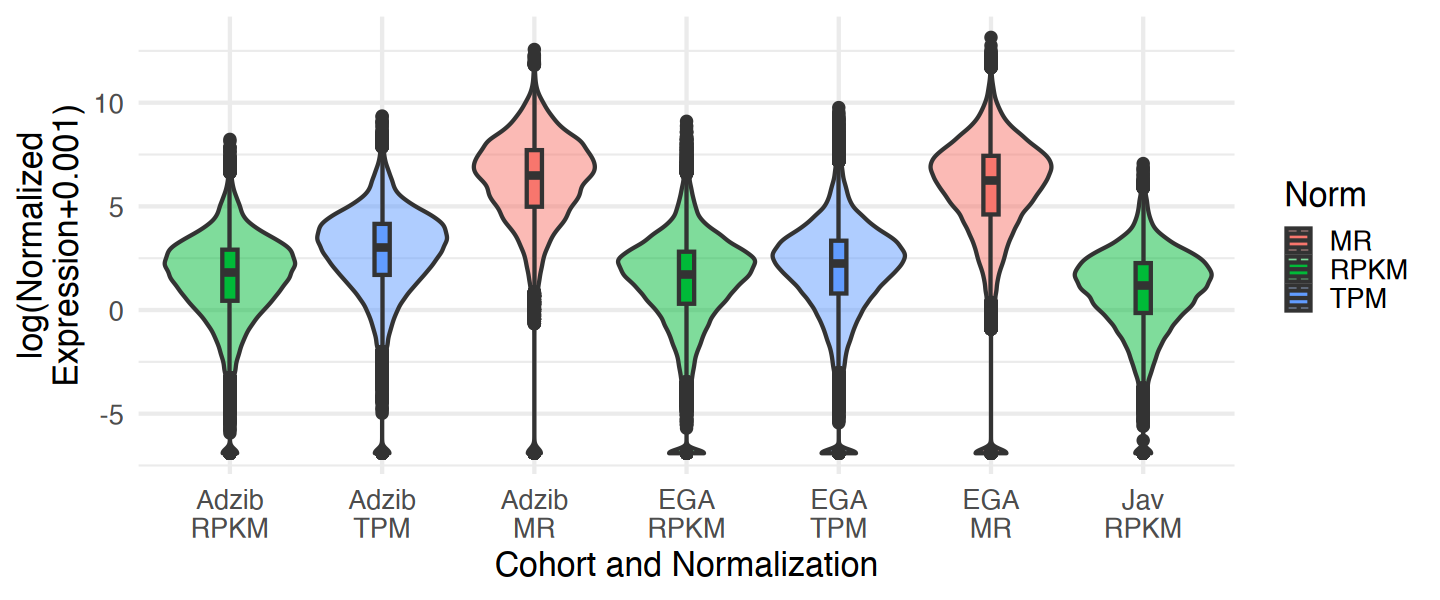

In [62]:
df <- bind_rows(
  as.data.frame(RNA_rpkm_matrix) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "Adzib\nRPKM", Norm="RPKM"),
  as.data.frame(RNA_rpkm_matrix_ega) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "EGA\nRPKM", Norm="RPKM"), 
  as.data.frame(RNA_norm_matrix) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "Adzib\nMR", Norm="MR"),
  as.data.frame(RNA_norm_matrix_ega) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "EGA\nMR", Norm="MR"),
  as.data.frame(RNA_tpm_matrix) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "Adzib\nTPM", Norm="TPM"),
  as.data.frame(RNA_tpm_matrix_ega) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "EGA\nTPM", Norm="TPM"),
  as.data.frame(RNA_rpkm_matrix_jav) %>% pivot_longer(everything(), values_to = "value") %>% mutate(Source = "Jav\nRPKM", Norm="RPKM")
)
df[1:2,]
library(ggplot2)
# Plot distributions
options(repr.plot.width=12, repr.plot.height=5)
ggplot(df, aes(x = factor(Source, levels=c("Adzib\nRPKM", "Adzib\nTPM", "Adzib\nMR", 
                                              "EGA\nRPKM", "EGA\nTPM", "EGA\nMR", "Jav\nRPKM")), y=log(value+0.001), fill = Norm)) +
  geom_violin(alpha = 0.5) + geom_boxplot(width=0.1) + labs(y="log(Normalized\nExpression+0.001)", x="Cohort and Normalization") +
  theme_minimal(base_size=20) 

## Get the counts of ALL genes with Nanostring genes being based on the transcripts or exons
(Used for WGCNA)

In [63]:
dim(rnaseq_gene_rpkm_jav_wgcna)
rnaseq_gene_ega_filt[1:2,]

[1] 14831    41

Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,17,324,295,126,...,6,16,14,11,22,44,169,251,532,338
MIR6859-1,chr1;chr1;chr1,17369;17369;17409,17436;17391;17431,-;-;-,68,4,2,10,15,...,0,2,1,0,5,4,26,33,12,21


In [64]:
# RNA-seq isoform based (Full)
rnaseq_ega_tpm[1:4,]
gene_topisoform_adzib_df[1:2,]

# only consider < 1TPM AND conenct back to Nano Names
gene_topisoform_adzib_filt_df <- gene_topisoform_adzib_df[gene_topisoform_adzib_df$Gene %in% rnaseq_gene_filt$Geneid,]
gene_topisoform_ega_filt_df <- gene_topisoform_ega_df[gene_topisoform_ega_df$Gene %in% rnaseq_gene_filt$Geneid,]

gene_topisoform_adzib_filt_df = merge(gene_topisoform_adzib_filt_df, compare_isof_df, by="Top_Isoform_Adzib", all.x=TRUE)
gene_topisoform_adzib_filt_df$Nano[is.na(gene_topisoform_adzib_filt_df$Nano)] <- gene_topisoform_adzib_filt_df$Gene[is.na(gene_topisoform_adzib_filt_df$Nano)]
dim(gene_topisoform_adzib_filt_df)
gene_topisoform_adzib_filt_df[1:13,]

gene_topisoform_ega_filt_df = merge(gene_topisoform_ega_filt_df, compare_isof_df, by="Top_Isoform_EGA", all.x=TRUE)
gene_topisoform_ega_filt_df$Nano[is.na(gene_topisoform_ega_filt_df$Nano)] <- gene_topisoform_ega_filt_df$Gene[is.na(gene_topisoform_ega_filt_df$Nano)]
dim(gene_topisoform_ega_filt_df)
gene_topisoform_ega_filt_df[1:13,]

# remove where < 1 TPM (based on the genes for easier and more consistent filtering across experiments)
rnaseq_gene_filt[1:2,]
rnaseq_ega_tpm_filt = rnaseq_ega_tpm[rnaseq_ega_tpm$Geneid %in% gene_topisoform_ega_filt_df$Top_Isoform_EGA,]
rnaseq_tpm_filt = rnaseq_tpm[rnaseq_tpm$Geneid %in% gene_topisoform_adzib_filt_df$Top_Isoform_Adzib,]
rnaseq_ega_rpkm_filt = rnaseq_ega_rpkm[rnaseq_ega_rpkm$Geneid %in% gene_topisoform_ega_filt_df$Top_Isoform_EGA,]
rnaseq_rpkm_filt = rnaseq_rpkm[rnaseq_rpkm$Geneid %in% gene_topisoform_adzib_filt_df$Top_Isoform_Adzib,]

dim(rnaseq_ega_tpm_filt)
dim(rnaseq_tpm_filt)
dim(rnaseq_ega_rpkm_filt)
dim(rnaseq_rpkm_filt)


Geneid,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.1151146,0.2199884,0.06605809,0.02775721,0.000000,0.1223199,0.4879202,0.000000,...,0.06620012,0.0000000,0.03183289,0.3451777,0.0958505,0.09788861,0.07730345,0.07094732,0.07879495,0.07243594
NR_024540.1,1.408456,6.9660669,6.0604380,3.88641120,7.72456997,1.120811,2.5416117,11.9445281,1.081763,...,0.98914730,0.5316618,0.32700244,1.4183309,1.3128285,5.14967484,4.52996490,7.04952503,8.29041039,2.36573437
NR_106918.1,8.621310,1.1186431,5.3444241,12.03617193,1.34867393,4.165366,7.4291325,1.6933699,0.000000,...,3.21654701,0.9879304,0.00000000,8.3857869,3.1048043,20.61035019,15.49365835,4.13664632,13.39977617,4.53907690
unassigned_transcript_1,0.000000,0.0000000,3.1601812,0.00000000,1.99369190,0.000000,0.0000000,0.0000000,0.000000,...,0.00000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000,0.00000000,5.09586866,26.41115304,0.00000000


Gene,Top_Isoform_Adzib
<chr>,<chr>
A1CF,NM_001370130.1
A2M,NM_001347425.2


[1] 17851    12

Top_Isoform_Adzib,Gene,Nano_Gene,hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Top_Isoform_EGA,Top_Isoform_Jim,Nano_OG,RNA_OG
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NM_000017.4,ACADS,NA,NA,ACADS,NA,NA,NA,NA,NA,NA,NA
NM_000024.6,ADRB2,NA,NA,ADRB2,NA,NA,NA,NA,NA,NA,NA
NM_000039.3,APOA1,NA,NA,APOA1,NA,NA,NA,NA,NA,NA,NA
NM_000048.4,ASL,NA,NA,ASL,NA,NA,NA,NA,NA,NA,NA
NM_000052.7,ATP7A,NA,NA,ATP7A,NA,NA,NA,NA,NA,NA,NA
NM_000054.7,AVPR2,NA,NA,AVPR2,NA,NA,NA,NA,NA,NA,NA
NM_000055.4,BCHE,NA,NA,BCHE,NA,NA,NA,NA,NA,NA,NA
NM_000056.5,BCKDHB,NA,NA,BCKDHB,NA,NA,NA,NA,NA,NA,NA
NM_000064.4,C3,NA,NA,C3,NA,NA,NA,NA,NA,NA,NA


[1] 17851    12

...

Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,38,91,52,73,...,123,56,45,53,62,73,32,62,47,58
MIR6859-1,chr1;chr1;chr1,17369;17369;17409,17436;17391;17431,-;-;-,68,5,13,5,7,...,5,2,1,2,10,6,1,7,2,11


[1] 17848   118

[1] 17848    50

[1] 17848   118

[1] 17848    50

In [65]:
# get the normalized matrices to have the same format (AND only have WGCNA genes as before)
row_names = rnaseq_ega_tpm_filt$Geneid
rnaseq_ega_tpm_filt <- as.data.frame(rnaseq_ega_tpm_filt)[, -which(colnames(rnaseq_ega_tpm_filt) %in% c("Geneid", "Median_TPM"))] 
rownames(rnaseq_ega_tpm_filt) <- row_names

row_names = rnaseq_tpm_filt$Geneid
rnaseq_tpm_filt <- as.data.frame(rnaseq_tpm_filt)[, -which(colnames(rnaseq_tpm_filt) %in% c("Geneid", "Median_TPM"))] 
rownames(rnaseq_tpm_filt) <- row_names

row_names = rnaseq_ega_rpkm_filt$Geneid
rnaseq_ega_rpkm_filt <- as.data.frame(rnaseq_ega_rpkm_filt)[, -which(colnames(rnaseq_ega_rpkm_filt) %in% c("Geneid", "Median_RPKM"))] 
rownames(rnaseq_ega_rpkm_filt) <- row_names

row_names = rnaseq_rpkm_filt$Geneid
rnaseq_rpkm_filt <- as.data.frame(rnaseq_rpkm_filt)[, -which(colnames(rnaseq_rpkm_filt) %in% c("Geneid", "Median_RPKM"))] 
rownames(rnaseq_rpkm_filt) <- row_names

# now attach the gene names to it
rnaseq_tpm_filt <- rnaseq_tpm_filt[gene_topisoform_adzib_filt_df$Top_Isoform_Adzib,]
rnaseq_ega_tpm_filt <- rnaseq_ega_tpm_filt[gene_topisoform_ega_filt_df$Top_Isoform_EGA,]
rnaseq_rpkm_filt <- rnaseq_rpkm_filt[gene_topisoform_adzib_filt_df$Top_Isoform_Adzib,]
rnaseq_ega_rpkm_filt <- rnaseq_ega_rpkm_filt[gene_topisoform_ega_filt_df$Top_Isoform_EGA,]

rownames(rnaseq_tpm_filt) <- str_split_fixed(gene_topisoform_adzib_filt_df$Nano, ":", 2)[,1]
rownames(rnaseq_ega_tpm_filt) <- str_split_fixed(gene_topisoform_ega_filt_df$Nano, ":", 2)[,1]
rownames(rnaseq_rpkm_filt) <- str_split_fixed(gene_topisoform_adzib_filt_df$Nano, ":", 2)[,1]
rownames(rnaseq_ega_rpkm_filt) <- str_split_fixed(gene_topisoform_ega_filt_df$Nano, ":", 2)[,1]

rnaseq_ega_tpm_filt[1:2,]
rnaseq_tpm_filt[1:2,]
rnaseq_ega_rpkm_filt[1:2,]
rnaseq_rpkm_filt[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_TPM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,4.966876,8.6952086,7.663312,9.128240,11.075232,3.2504346,7.255693,9.477042,1.821232,9.560774,...,1.758625,1.588376,1.626179,2.036757,2.5152850,2.896036,85.62587,4.1904377,5.5355552,8.4258743
ADRB2,2.475468,0.2834118,1.191544,2.087147,2.551292,0.7504419,2.760552,1.544475,2.632543,3.707469,...,1.152576,1.195220,1.535145,6.687785,0.9631366,9.229582,30.44652,0.6185428,0.1164481,0.5388692


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,38.637407,53.097327,20.80699,14.88240,14.93165,10.529881,17.69492,23.456342,17.245575,12.341758,...,13.245278,12.761099,10.19953,11.05307,12.319732,11.350428,16.275161,9.859075,17.220909,20.426587
ADRB2,6.033613,3.564382,12.91440,14.99752,11.77139,3.834942,8.52585,1.017885,3.095733,3.875177,...,2.652066,3.002507,13.72051,12.39224,9.595954,4.452569,6.897857,6.790685,5.660554,3.710931


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_RPKM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,1.819951,6.853373,6.3581579,6.608171,7.856129,1.511879,5.992834,4.8279673,0.6053336,6.318173,...,0.8918203,0.6201519,0.6057271,0.7282434,0.8802394,1.093075,42.17609,2.9619957,5.0427708,6.0964744
ADRB2,0.907055,0.223379,0.9886095,1.510940,1.809739,0.349054,2.280076,0.7868143,0.8749940,2.450056,...,0.5844858,0.4666514,0.5718181,2.3912207,0.3370555,3.483600,14.99681,0.4372148,0.1060817,0.3898946


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_RPKM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,11.317060,16.304143,6.164085,4.403725,4.236303,2.6419469,5.521237,6.4738079,4.9066759,3.385574,...,3.7366822,3.5726067,3.306355,3.268939,3.547411,3.202878,4.508161,2.708420,5.126218,5.892225
ADRB2,1.767271,1.094484,3.825900,4.437788,3.339695,0.9621868,2.660268,0.2809301,0.8807917,1.063033,...,0.7481857,0.8405841,4.447741,3.664997,2.763112,1.256432,1.910682,1.865492,1.685000,1.070450


In [66]:
# FULL GENE NOW
# get the normalized matrices to have the same format (AND only have WGCNA genes as before)
row_names = rnaseq_gene_tpm_wgcna$Geneid
rnaseq_gene_tpm <- as.data.frame(rnaseq_gene_tpm_wgcna)[, -which(colnames(rnaseq_gene_tpm_wgcna) %in% c("Geneid", "Median_TPM"))] 
rownames(rnaseq_gene_tpm) <- row_names

row_names = rnaseq_gene_rpkm_wgcna$Geneid
rnaseq_gene_rpkm <- as.data.frame(rnaseq_gene_rpkm_wgcna)[, -which(colnames(rnaseq_gene_rpkm_wgcna) %in% c("Geneid", "Median_RPKM"))] 
rownames(rnaseq_gene_rpkm) <- row_names

row_names = rnaseq_gene_ega_tpm_wgcna$Geneid
rnaseq_gene_ega_tpm <- as.data.frame(rnaseq_gene_ega_tpm_wgcna)[, -which(colnames(rnaseq_gene_ega_tpm_wgcna) %in% c("Geneid", "Median_TPM"))] 
rownames(rnaseq_gene_ega_tpm) <- row_names

row_names = rnaseq_gene_ega_rpkm_wgcna$Geneid
rnaseq_gene_ega_rpkm <- as.data.frame(rnaseq_gene_ega_rpkm_wgcna)[, -which(colnames(rnaseq_gene_ega_rpkm_wgcna) %in% c("Geneid", "Median_RPKM"))] 
rownames(rnaseq_gene_ega_rpkm) <- row_names

row_names = rnaseq_gene_rpkm_jav_wgcna$Geneid
rnaseq_gene_jav_rpkm <- as.data.frame(rnaseq_gene_rpkm_jav_wgcna)[, -which(colnames(rnaseq_gene_rpkm_jav_wgcna) %in% c("Geneid", "Median_RPKM"))] 
rownames(rnaseq_gene_jav_rpkm) <- row_names

rnaseq_gene_tpm[1:2,]
rnaseq_gene_rpkm[1:2,]
rnaseq_gene_ega_tpm[1:2,]
rnaseq_gene_ega_rpkm[1:2,]
rnaseq_gene_jav_rpkm[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,2.249153,3.449513,2.644208,3.857054,1.243824,1.714389,3.855855,5.212274,1.909914,8.196825,...,7.575465,4.783304,2.788034,2.160058,4.053959,3.852816,2.64397,2.676506,3.604072,4.082024
MIR6859-1,7.698823,12.819724,6.614259,9.621655,2.489055,0.000000,3.235772,5.649824,3.312391,9.447253,...,8.011118,4.444152,1.611775,2.120501,17.010088,8.238071,2.14944,7.861283,3.989739,20.139984


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_RPKM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,0.6587864,1.059213,0.7833486,1.141308,0.3528889,0.4301402,1.203119,1.438556,0.5434049,2.248542,...,2.137147,1.339137,0.9037897,0.6388359,1.167319,1.087192,0.7323702,0.7352721,1.072839,1.177495
MIR6859-1,2.2550178,3.936443,1.9594792,2.847062,0.7061771,0.0000000,1.009638,1.559317,0.9424346,2.591557,...,2.260051,1.244188,0.5224850,0.6271369,4.897978,2.324629,0.5953873,2.1596001,1.187642,5.809552


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_TPM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,1.408456,6.966067,6.060438,3.886411,7.724570,1.120811,2.541612,11.94453,1.081763,1.731433,...,0.3576961,0.9891473,0.5316618,0.3270024,1.418331,1.312828,5.149675,4.529965,7.049525,8.29041
MIR6859-1,8.621310,1.118643,5.344424,12.036172,1.348674,4.165366,7.429133,1.69337,0.000000,3.806427,...,0.0000000,3.2165470,0.9879304,0.0000000,8.385787,3.104804,20.610350,15.493658,4.136646,13.39978


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam_RPKM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,0.516083,5.490502,5.028273,2.813475,5.4793633,0.5213242,2.099242,6.0849991,0.3595521,1.144206,...,0.1813921,0.3861943,0.1980360,0.1169199,0.4963536,0.495512,2.536537,3.201989,6.421964,5.998461
MIR6859-1,3.158999,0.881690,4.434205,8.713300,0.9566713,1.9374421,6.136086,0.8626674,0.0000000,2.515452,...,0.0000000,1.2558414,0.3679891,0.0000000,2.9346574,1.171873,10.151886,10.951636,3.768395,9.695302


,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,PJ_12_Post,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.86421,1.23668,0.713873,0.923893,0.513896,1.23645,0.59655,0.372954,1.59019,1.62249,...,1.09215,0.924075,0.983682,0.44261,2.01262,0.85192,1.44594,0.93678,0.944465,0.808788
A2M,30.11540,86.22660,25.258000,68.798800,62.189700,87.53930,21.77850,25.871700,10.90290,36.88500,...,22.64580,63.530900,109.064000,46.10920,49.93510,46.79910,16.38070,28.85610,41.199300,101.030000


In [53]:
rnaseq_gene_cpm_filt = subset(rnaseq_gene_cpm, !rownames(rnaseq_gene_cpm) %in% rownames(rnaseq_gene_rpkm_jav_wgcna))
rnaseq_gene_cpm_ega_filt = subset(rnaseq_gene_ega_cpm, !rownames(rnaseq_gene_ega_cpm) %in% rownames(rnaseq_gene_rpkm_jav_wgcna))
rnaseq_gene_cpm_filt[1:2,]
rnaseq_gene_cpm_ega_filt[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
WASH7P,1.2116617,1.8263300,1.402689,2.0032709,0.70483492,0.8536558,2.08840908,2.4937745,0.93979447,3.9496935,...,3.5284856,2.2600507,1.48682443,1.02986934,1.8873513,1.9155048,1.33239907,1.3953923,1.70118822,1.9353035
MIR6859-1,0.1594292,0.2609043,0.134874,0.1920945,0.05421807,0.0000000,0.06736803,0.1039073,0.06265296,0.1749864,...,0.1434344,0.0807161,0.03304054,0.03886299,0.3044115,0.1574388,0.04163747,0.1575443,0.07239099,0.3670403


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
WASH7P,0.7813911,9.48572643,8.9136921,4.4722725,9.7952742,0.8691731,3.9344437,9.65315385,0.569116,2.2140670,...,0.3254833,0.66640123,0.35224665,0.2441536,0.7426484,0.84522305,4.4065826,5.3933613,12.7809529,10.3375651
MIR6859-1,0.1838567,0.05855387,0.3021591,0.5324134,0.0657401,0.1241676,0.4420723,0.05260574,0.000000,0.1871042,...,0.0000000,0.08330015,0.02516047,0.0000000,0.1687837,0.07683846,0.6779358,0.7090873,0.2882922,0.6422748


In [67]:
rnaseq_gene_ega_cpm_filt <- subset(rnaseq_gene_ega_cpm, !rownames(rnaseq_gene_ega_cpm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_ega_cpm_filt)))
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_ega_cpm)))
dim(rnaseq_gene_ega_cpm_filt)

rnaseq_gene_cpm_filt <- subset(rnaseq_gene_cpm, !rownames(rnaseq_gene_cpm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_cpm_filt)))
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_cpm)))
dim(rnaseq_gene_cpm_filt)

[1] 0

[1] 756

[1] 17265   116

[1] 0

[1] 756

[1] 17265    48

In [68]:
# What genes are in full that are NanoString and therefore need to be removed so not double integrated
length(intersect(rownames(nano_matrix), rownames(rnaseq_gene_norm)))
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_norm)))

rnaseq_gene_norm_filt <- subset(rnaseq_gene_norm, !rownames(rnaseq_gene_norm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_norm_filt)))
rnaseq_gene_tpm_filt <- subset(rnaseq_gene_tpm, !rownames(rnaseq_gene_tpm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_tpm_filt)))
rnaseq_gene_rpkm_filt <- subset(rnaseq_gene_rpkm, !rownames(rnaseq_gene_rpkm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_rpkm_filt)))


rnaseq_gene_norm_ega_filt <- subset(rnaseq_gene_norm_ega, !rownames(rnaseq_gene_norm_ega) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_norm_ega_filt)))
rnaseq_gene_ega_tpm_filt <- subset(rnaseq_gene_ega_tpm, !rownames(rnaseq_gene_ega_tpm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_ega_tpm_filt)))
rnaseq_gene_ega_rpkm_filt <- subset(rnaseq_gene_ega_rpkm, !rownames(rnaseq_gene_ega_rpkm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_ega_rpkm_filt)))


rnaseq_gene_jav_rpkm_filt <- subset(rnaseq_gene_jav_rpkm, !rownames(rnaseq_gene_jav_rpkm) %in% compare_df$hg38pt14_Gene)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_jav_rpkm_filt)))

[1] 756

[1] 756

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

In [70]:
# reintroduce the transcript based counts for Nanostring
wgnca_norm_counts <- rbind(rnaseq_gene_norm_filt, RNA_norm_matrix)
dim(wgnca_norm_counts)
wgnca_tpm_counts <- rbind(rnaseq_gene_tpm_filt, RNA_tpm_matrix)
dim(wgnca_tpm_counts)
wgnca_rpkm_counts <- rbind(rnaseq_gene_rpkm_filt, RNA_rpkm_matrix)
dim(wgnca_rpkm_counts)
wgnca_cpm_counts <- rbind(rnaseq_gene_cpm_filt, RNA_cpm_matrix)
dim(wgnca_cpm_counts)

wgnca_norm_counts_ega <- rbind(rnaseq_gene_norm_ega_filt, RNA_norm_matrix_ega)
dim(wgnca_norm_counts_ega)
wgnca_tpm_counts_ega <- rbind(rnaseq_gene_ega_tpm_filt, RNA_tpm_matrix_ega)
dim(wgnca_tpm_counts_ega)
wgnca_rpkm_counts_ega <- rbind(rnaseq_gene_ega_rpkm_filt, RNA_rpkm_matrix_ega)
dim(wgnca_rpkm_counts_ega)
wgnca_cpm_counts_ega <- rbind(rnaseq_gene_ega_cpm_filt, RNA_cpm_matrix_ega)
dim(wgnca_cpm_counts_ega)

wgnca_rpkm_counts_jav <- rbind(rnaseq_gene_jav_rpkm_filt, RNA_rpkm_matrix_jav)
dim(wgnca_rpkm_counts_jav)
# check all the Nano genes are now accounted for
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_norm_counts)))
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_tpm_counts)))
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_rpkm_counts)))
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_norm_counts_ega)))
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_tpm_counts_ega)))
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_rpkm_counts_ega)))
length(intersect(str_split_fixed(compare_df$Nano, ":", 2)[,1], rownames(wgnca_rpkm_counts_jav)))

[1] 18035    48

[1] 18035    48

[1] 18035    48

[1] 18035    48

[1] 18035   116

...

[1] 770

[1] 770

[1] 770

[1] 770

[1] 770

# Clean up the names of columns


### Adzib

In [71]:
Adzib_meta <- fread(here("../RNASeq/Adzib//counts/Adzibolosu_metadata_09.11.24.txt"))

In [72]:
Adzib_meta[1:3,]

geo_accession,description,title,time,patientid,recurrence,disease_state,library_strategy,SRR,Name
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM7091663,USF1_Pre,"Late Recurrence, Patient 1, Pre-Chemo",Pre-Chemo,USF1,Late,HGSOC,RNA-Seq,SRR23803466,USF1_Pre
GSM7091664,USF1_Post,"Late Recurrence, Patient 1, Post-Chemo",Post-Chemo,USF1,Late,HGSOC,RNA-Seq,SRR23803465,USF1_Post
GSM7091665,USF3_Pre,"Early Recurrence, Patient 1, Pre-Chemo",Pre-Chemo,USF3,Early,HGSOC,RNA-Seq,SRR23803464,USF3_Pre


In [73]:
rnaseq_gene_cpm[1:2,]

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
WASH7P,1.2116617,1.8263300,1.402689,2.0032709,0.70483492,0.8536558,2.08840908,2.4937745,0.93979447,3.9496935,...,3.5284856,2.2600507,1.48682443,1.02986934,1.8873513,1.9155048,1.33239907,1.3953923,1.70118822,1.9353035
MIR6859-1,0.1594292,0.2609043,0.134874,0.1920945,0.05421807,0.0000000,0.06736803,0.1039073,0.06265296,0.1749864,...,0.1434344,0.0807161,0.03304054,0.03886299,0.3044115,0.1574388,0.04163747,0.1575443,0.07239099,0.3670403


In [77]:
RNA_norm_matrix[1:3,]
rnaseq_tpm_filt[1:2,]
rnaseq_rpkm_filt[1:2,]

identical(colnames(RNA_tpm_matrix), colnames(rnaseq_tpm_filt))
identical(colnames(RNA_norm_matrix), colnames(RNA_cpm_matrix))
identical(paste0(colnames(RNA_norm_matrix), "_RPKM"), colnames(rnaseq_rpkm_filt))
identical(colnames(wgnca_cpm_counts), colnames(wgnca_norm_counts))
identical(colnames(wgnca_cpm_counts), colnames(RNA_norm_matrix))

,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam
A2M,28683.57960,12629.32044,53905.8375,51450.9234,13127.70292,21501.577767,53355.4915,9671.4243,13477.3128,21726.3049,...,17178.32153,15949.53756,36805.19684,42254.33020,42714.09593,19898.14177,30358.3615,29133.98854,25373.4792,15560.4102
ABCF1,3351.88586,2264.05806,3452.2653,3043.8563,4480.66592,3266.081738,4003.6763,5342.8831,5077.9859,5686.0397,...,3821.88502,4755.19746,4332.11134,4579.95429,3852.24752,3931.88271,2345.8810,2867.79974,5587.2016,6106.3626
ACVR1C,51.93776,27.87929,148.3263,82.9954,80.53805,7.620349,162.4719,113.2021,101.4811,144.0798,...,11.98766,28.46527,62.42941,34.61681,42.12079,69.43092,231.2606,31.13193,164.4166,134.6692


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_TPM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_TPM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_TPM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,38.637407,53.097327,20.80699,14.88240,14.93165,10.529881,17.69492,23.456342,17.245575,12.341758,...,13.245278,12.761099,10.19953,11.05307,12.319732,11.350428,16.275161,9.859075,17.220909,20.426587
ADRB2,6.033613,3.564382,12.91440,14.99752,11.77139,3.834942,8.52585,1.017885,3.095733,3.875177,...,2.652066,3.002507,13.72051,12.39224,9.595954,4.452569,6.897857,6.790685,5.660554,3.710931


,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803419.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803420.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803421.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803422.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803423.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803424.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803425.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803426.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803427.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803428.sorted.bam_RPKM,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803457.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803458.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803459.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803460.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803461.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803462.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803463.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803464.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803465.sorted.bam_RPKM,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/Adzibolosu_fw_gg_09.4.24/mapped/bams/SRR23803466.sorted.bam_RPKM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,11.317060,16.304143,6.164085,4.403725,4.236303,2.6419469,5.521237,6.4738079,4.9066759,3.385574,...,3.7366822,3.5726067,3.306355,3.268939,3.547411,3.202878,4.508161,2.708420,5.126218,5.892225
ADRB2,1.767271,1.094484,3.825900,4.437788,3.339695,0.9621868,2.660268,0.2809301,0.8807917,1.063033,...,0.7481857,0.8405841,4.447741,3.664997,2.763112,1.256432,1.910682,1.865492,1.685000,1.070450


[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

In [75]:
dim(wgnca_cpm_counts_ega)


[1] 18035   116

In [78]:
new_colnames = c()
for (og_name in colnames(RNA_norm_matrix)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, Adzib_meta[Adzib_meta$SRR == srr,]$Name[1])
    }
new_colnames

colnames(RNA_norm_matrix) <- new_colnames
colnames(RNA_cpm_matrix) <- new_colnames
colnames(RNA_matrix) <- new_colnames
colnames(wgnca_norm_counts) <- new_colnames
colnames(wgnca_cpm_counts) <- new_colnames


[1] "WSU_F_Post" "WSU_F_Pre"  "WSU_E_Post" "WSU_E_Pre"  "USF39_Post"
 [6] "USF39_Pre"  "USF37_Post" "USF37_Pre"  "USF36_Post" "USF36_Pre" 
[11] "USF35_Post" "USF35_Pre"  "USF34_Post" "USF34_Pre"  "USF33_Post"
[16] "USF33_Pre"  "USF31_Post" "USF31_Pre"  "WSU14_Post" "WSU14_Pre" 
[21] "WSU12_Post" "WSU12_Pre"  "WSU11_Post" "WSU11_Pre"  "WSU9_Post" 
[26] "WSU9_Pre"   "WSU6_Post"  "WSU6_Pre"   "WSU2_Post"  "WSU2_Pre"  
[31] "USF18_Post" "USF18_Pre"  "USF17_Post" "USF17_Pre"  "USF16_Post"
[36] "USF16_Pre"  "USF15_Post" "USF15_Pre"  "USF14_Post" "USF14_Pre" 
[41] "USF10_Post" "USF10_Pre"  "USF7_Post"  "USF7_Pre"   "USF3_Post" 
[46] "USF3_Pre"   "USF1_Post"  "USF1_Pre"

In [79]:
new_colnames = c()
for (og_name in colnames(RNA_tpm_matrix)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, Adzib_meta[Adzib_meta$SRR == srr,]$Name[1])
    }
new_colnames
if (identical(colnames(wgnca_tpm_counts), colnames(RNA_tpm_matrix))) {
    colnames(RNA_tpm_matrix) <- new_colnames
    colnames(wgnca_tpm_counts) <- new_colnames
	colnames(rnaseq_tpm_filt) <- new_colnames
    }


[1] "WSU_F_Post" "WSU_F_Pre"  "WSU_E_Post" "WSU_E_Pre"  "USF39_Post"
 [6] "USF39_Pre"  "USF37_Post" "USF37_Pre"  "USF36_Post" "USF36_Pre" 
[11] "USF35_Post" "USF35_Pre"  "USF34_Post" "USF34_Pre"  "USF33_Post"
[16] "USF33_Pre"  "USF31_Post" "USF31_Pre"  "WSU14_Post" "WSU14_Pre" 
[21] "WSU12_Post" "WSU12_Pre"  "WSU11_Post" "WSU11_Pre"  "WSU9_Post" 
[26] "WSU9_Pre"   "WSU6_Post"  "WSU6_Pre"   "WSU2_Post"  "WSU2_Pre"  
[31] "USF18_Post" "USF18_Pre"  "USF17_Post" "USF17_Pre"  "USF16_Post"
[36] "USF16_Pre"  "USF15_Post" "USF15_Pre"  "USF14_Post" "USF14_Pre" 
[41] "USF10_Post" "USF10_Pre"  "USF7_Post"  "USF7_Pre"   "USF3_Post" 
[46] "USF3_Pre"   "USF1_Post"  "USF1_Pre"

In [80]:
new_colnames = c()
for (og_name in colnames(RNA_rpkm_matrix)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, Adzib_meta[Adzib_meta$SRR == srr,]$Name[1])
    }
new_colnames
if (identical(colnames(wgnca_rpkm_counts), colnames(RNA_rpkm_matrix))) {
    colnames(RNA_rpkm_matrix) <- new_colnames
    colnames(wgnca_rpkm_counts) <- new_colnames
	colnames(rnaseq_rpkm_filt) <- new_colnames
    }

[1] "WSU_F_Post" "WSU_F_Pre"  "WSU_E_Post" "WSU_E_Pre"  "USF39_Post"
 [6] "USF39_Pre"  "USF37_Post" "USF37_Pre"  "USF36_Post" "USF36_Pre" 
[11] "USF35_Post" "USF35_Pre"  "USF34_Post" "USF34_Pre"  "USF33_Post"
[16] "USF33_Pre"  "USF31_Post" "USF31_Pre"  "WSU14_Post" "WSU14_Pre" 
[21] "WSU12_Post" "WSU12_Pre"  "WSU11_Post" "WSU11_Pre"  "WSU9_Post" 
[26] "WSU9_Pre"   "WSU6_Post"  "WSU6_Pre"   "WSU2_Post"  "WSU2_Pre"  
[31] "USF18_Post" "USF18_Pre"  "USF17_Post" "USF17_Pre"  "USF16_Post"
[36] "USF16_Pre"  "USF15_Post" "USF15_Pre"  "USF14_Post" "USF14_Pre" 
[41] "USF10_Post" "USF10_Pre"  "USF7_Post"  "USF7_Pre"   "USF3_Post" 
[46] "USF3_Pre"   "USF1_Post"  "USF1_Pre"

### EGA

In [81]:
# read in the metadata
full_meta <- fread("../../../Harmonization/FullPatient_metadata_8.20.25.txt")
table(full_meta$Source)

ega_full_meta <- full_meta[full_meta$Source %in% c("Piet", "Zhang", "Zhang_Piet"),]
ega_full_meta[1:2,]

ega_meta <- fread("../../../EGA_rel_data/Harmonized_EGA_pat_data.txt")
ega_meta[1:2,]

ega_samps <- readxl::read_excel("../../../EGA_rel_data/Final_Samples.xlsx")
ega_samps[1:2,]


              Adzib_2023 CU Anschutz, unpublished                    James 
                      15                       29                       31 
                   Manso            PMID:32928797                     Piet 
                      17                        6                        7 
                   Zhang               Zhang_Piet 
                       3                       19 

Patient,Death,Stage,Source,Age,PFS_mths,PFI_mths,PFI_days,OS_mths,CRS,...,Chemo_status,Chemo_regimen,PFS_high,PFS_high_32928797,Manso_Response,James_Prog_status_4.25.22,Res_Tumor_afterPDS,CA125_Uperml_TN,CA125_Uperml_PN,uniq_patient_name
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,...,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
EOC1005,0,IVA,Piet,73,9.133333,29.86667,896,30,2,...,NA,CP-TX-BV,NA,NA,NA,NA,1-10 mm,3776,343,EOC1005_Piet
EOC136,0,IVA,Piet,64,23.833333,33.53333,1006,34,2,...,NA,CP-TX,NA,NA,NA,NA,1-10 mm,2647,212,EOC136_Piet


Patient,Data_Found_In,PlatFI_12_months,PlatFI_days,FIGO_Stage,Tissues,Sample_stages,Response_to_Treatment,Age,OvaHRDscar,BRCAmut_status,CRS,CA125_Uperml_TN_PN,Piet21_Survival,Piet21Residual_tumor_after_DS,Piet21_Primary_chemo_regimen,Piet21_Progression_free_survival_mths,Piet21_Overall_survival_mths,Piet21_Relapse_type
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S033,Launonen_2024,short,NotinData,IVA,"omentum,NA","IDS,chemo-naive",NotinData,NotinData,HRP,BRCAwt,NotinData,NotinData,NotinData,NotinData,NotinData,NotinData,NotinData,NotinData
S034,Launonen_2024,short,NotinData,IIIC,"omentum,NA","IDS,chemo-naive",NotinData,NotinData,HRP,BRCAwt,NotinData,NotinData,NotinData,NotinData,NotinData,NotinData,NotinData,NotinData


New names:
* `` -> `...27`
* `` -> `...28`
* `` -> `...29`


Patient,Final_Bool,Assay,SC_Match,ExtraID,MultiQC Notes,RNAseqID,Twin,OG_Tissue,Twin_Tissue,...,PFI_daysZhang,CRS,CA125_Uperml_TN,CA125_Uperml_PN,Age_Zhang,Final_PFI_days,PFI_source,...27,...28,...29
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>
EOC1005,Y,SC,SC,NA,NA,EOC1005_primary_Peritoneum,EOC1005_interval_Tumor,Peritoneum,Tumor,...,65,2,3776,343,73,896,Piet,NA,29.86667,2.166667
EOC1005,Y,SC,NA,NA,NA,EOC1005_interval_Tumor,EOC1005_primary_Peritoneum,Tumor,Peritoneum,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [82]:
# all relevant samples to keep for L2FC have the Final_Bool of Y (or Backup)
ega_samps$Name <- paste0(ega_samps$Patient, "_", ega_samps$Timing)
ega_samps[ega_samps$Final_Bool == "Backup",]$Name <- paste0(ega_samps[ega_samps$Final_Bool == "Backup",]$Name, "_Backup")
ega_samps[ega_samps$Final_Bool == "Extra",]$Name <- paste0(ega_samps[ega_samps$Final_Bool == "Extra",]$Name, "_Extra")
ega_samps_bulk = ega_samps[ega_samps$Assay == "Bulk" & ega_samps$Final_Bool %in% c("Y", "Backup", "Extra"),]
ega_samps_bulk[1:4,]


Patient,Final_Bool,Assay,SC_Match,ExtraID,MultiQC Notes,RNAseqID,Twin,OG_Tissue,Twin_Tissue,...,CRS,CA125_Uperml_TN,CA125_Uperml_PN,Age_Zhang,Final_PFI_days,PFI_source,...27,...28,...29,Name
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<chr>
EOC1005,Extra,Bulk,Bulk,NA,28M,EOC1005_pPer1_RNA_seq6,NA,Peritoneum,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,EOC1005_Pre_Extra
EOC136,Y,Bulk,Bulk,9003,9003_L1: 17.7M; 9003_L2: 17.7M (35M); 7141_L1: 14.2M; 7141_L2: 13.1M,EOC136_pMes1_RNA1_seq6b,EOC136_iOme1_RNA1_seq6,Mesentery,Omentum,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,EOC136_Pre
EOC136,Y,Bulk,Bulk,7141,7141_L1: 12.6M; 7141_L2: 11.7M (24M); 9003_L1: 6.8M; 9003_L2: 6.8M,EOC136_iOme1_RNA1_seq6,EOC136_pMes1_RNA1_seq6b,Omentum,Mesentery,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,EOC136_Post
EOC3,Y,Bulk,Bulk,NA,20M,EOC3_pPer1_RNA1_seq6,EOC3_iOme2_RNA1_seq6a,Peritoneum,Omentum,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,EOC3_Pre


In [83]:
identical(colnames(RNA_norm_matrix_ega), colnames(RNA_matrix_ega))
identical(colnames(RNA_norm_matrix_ega), colnames(wgnca_norm_counts_ega))
identical(colnames(wgnca_tpm_counts_ega), colnames(RNA_tpm_matrix_ega))
identical(colnames(wgnca_rpkm_counts_ega), colnames(RNA_rpkm_matrix_ega))
identical(colnames(rnaseq_ega_tpm_filt), colnames(RNA_tpm_matrix_ega))
identical(colnames(rnaseq_ega_rpkm_filt), colnames(RNA_rpkm_matrix_ega))
identical(colnames(RNA_cpm_matrix_ega), colnames(wgnca_norm_counts_ega))
identical(colnames(RNA_cpm_matrix_ega), colnames(wgnca_cpm_counts_ega))

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

In [84]:
# only keep the relevant part of the names
new_colnames = c()
for (og_name in colnames(RNA_norm_matrix_ega)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, srr)
    }
colnames(RNA_norm_matrix_ega) <- new_colnames
colnames(RNA_matrix_ega) <- new_colnames
colnames(wgnca_norm_counts_ega) <- new_colnames
colnames(RNA_cpm_matrix_ega) <- new_colnames
colnames(wgnca_cpm_counts_ega) <- new_colnames
RNA_matrix_ega[1:3,]

new_colnames = c()
for (og_name in colnames(RNA_tpm_matrix_ega)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, srr)
    }
colnames(RNA_tpm_matrix_ega) <- new_colnames
colnames(wgnca_tpm_counts_ega) <- new_colnames
colnames(rnaseq_ega_tpm_filt) <- new_colnames

new_colnames = c()
for (og_name in colnames(RNA_rpkm_matrix_ega)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, srr)
    }
colnames(RNA_rpkm_matrix_ega) <- new_colnames
colnames(wgnca_rpkm_counts_ega) <- new_colnames
colnames(rnaseq_ega_rpkm_filt) <- new_colnames


,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219,EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206,EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205,EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207,EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517,EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208,EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211,EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518,EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209,...,EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533,EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530,EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530,EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521,EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522,EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523,EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206,EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205,EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214,EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216
A2M,11072,2171,6688,6885,18258,13660,20746,11234,6320,20973,...,4428,6360,10864,34496,8479,16015,62662,5506,3535,7404
ABCF1,1886,2227,1722,1670,1229,3960,1188,1714,1315,1800,...,744,1547,2516,3515,1622,3501,2019,3480,1728,1824
ACVR1C,84,103,121,95,131,244,64,239,179,57,...,60,58,76,150,255,299,5116,124,558,222


In [85]:
# atach the full names to the appropriate counts
RNAseq_Full_Name <- c()
# now only keep those that have the appropriate connections
for (index in seq(1, nrow(ega_samps_bulk))) {
    # get the Name
    name_use <- ega_samps_bulk$Name[index]
    # get the corresponding sample
    if (is.na(ega_samps_bulk$ExtraID[index])) {
        # if no extra id (due to technical replicates) then just get the sample
        sample <- colnames(RNA_norm_matrix_ega)[grepl(ega_samps_bulk$RNAseqID[index], colnames(RNA_norm_matrix_ega))]
        } else {
        sample <- colnames(RNA_norm_matrix_ega)[grepl(ega_samps_bulk$RNAseqID[index], colnames(RNA_norm_matrix_ega)) & 
                             grepl(ega_samps_bulk$ExtraID[index], colnames(RNA_norm_matrix_ega))]
        }
    # check that only ONE sample is found
    if (length(sample) != 1) {
        stop("MORE THAN ONE OR NO SAMPLE WAS FOUND:", ega_samps_bulk$RNAseqID[index], sample)
        }
    # sample the EXACT sample name to the metadata
    RNAseq_Full_Name <- c(RNAseq_Full_Name, sample)
    }
ega_samps_bulk$RNAseq_Full_Name <- RNAseq_Full_Name

In [86]:
# only keep the counts for patients with clinical data 
ncol(RNA_norm_matrix_ega)
RNA_norm_matrix_ega <- RNA_norm_matrix_ega[,ega_samps_bulk$RNAseq_Full_Name]
RNA_norm_matrix_ega[1:2,]
ncol(RNA_norm_matrix_ega)

ncol(RNA_cpm_matrix_ega)
RNA_cpm_matrix_ega <- RNA_cpm_matrix_ega[,ega_samps_bulk$RNAseq_Full_Name]
RNA_cpm_matrix_ega[1:2,]
ncol(RNA_cpm_matrix_ega)

ncol(RNA_matrix_ega)
RNA_matrix_ega <- RNA_matrix_ega[,ega_samps_bulk$RNAseq_Full_Name]
RNA_matrix_ega[1:2,]
ncol(RNA_matrix_ega)
identical(colnames(RNA_matrix_ega), colnames(RNA_norm_matrix_ega))


ncol(wgnca_norm_counts_ega)
wgnca_norm_counts_ega <- wgnca_norm_counts_ega[,ega_samps_bulk$RNAseq_Full_Name]
wgnca_norm_counts_ega[1:2,]
ncol(wgnca_norm_counts_ega)

ncol(wgnca_cpm_counts_ega)
wgnca_cpm_counts_ega <- wgnca_cpm_counts_ega[,ega_samps_bulk$RNAseq_Full_Name]
wgnca_cpm_counts_ega[1:2,]
ncol(wgnca_cpm_counts_ega)



[1] 116

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
A2M,19753.606,4034.5366,8377.418,4199.107,20682.437,17320.617,22033.234,10043.453,66439.16,16868.593,...,31180.407,9674.176,25.69594,7857.428,30623.256,11239.47,4844.909,25805.95,14499.332,12249.887
ABCF1,3364.821,854.5161,1653.422,4217.714,3600.639,3402.057,2119.502,1863.721,2170.85,2754.877,...,1481.817,1204.537,1994.53626,1777.421,1263.306,2433.45,1770.558,2907.25,3199.314,2812.556


[1] 74

[1] 116

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
A2M,569.22720,221.53811,379.43900,178.2044,634.9096,405.89028,819.63621,470.54985,2109.41421,522.50323,...,965.28488,414.67018,1.222243,262.60884,1092.07649,416.54046,195.75421,503.29731,472.3996,437.9432
ABCF1,98.38366,48.24474,76.10618,186.5852,112.6441,81.02609,79.91684,88.51782,69.13302,85.62212,...,46.59902,52.52839,98.259605,60.41295,45.20862,91.35303,73.12041,57.59662,105.7047,101.8913


...

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
WASH7P,30.329778,4.577765,4.744396,16.9148333,23.942475,195.77054,166.27379,138.00734,338.88377,484.66075,...,171.17841,54.242891,176.32728,245.77448,318.10581,127.91791,90.940633,167.15518,125.61863,155.22204
MIR6859-1,7.136418,0.000000,0.000000,0.8457417,2.317014,21.75228,14.67122,11.81144,45.84898,29.62991,...,28.52974,6.026988,12.40493,38.61295,31.40535,18.81146,9.279656,31.24396,10.18529,15.18476


[1] 74

[1] 116

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
WASH7P,0.7813911,0.2528333,0.2010528,0.70541186,0.67173457,4.4278131,5.3233897,5.8715272,9.856946,13.6621363,...,4.8288281,2.1659090,7.2118552,7.777337,10.0913970,4.2727345,3.596805,3.1516399,3.8482372,5.1811723
MIR6859-1,0.1838567,0.0000000,0.0000000,0.03527059,0.06500657,0.4919792,0.4697109,0.5025181,1.333587,0.8352398,...,0.8048047,0.2406566,0.5073667,1.221876,0.9962844,0.6283433,0.367021,0.5890916,0.3120192,0.5068538


[1] 74

In [87]:
ncol(RNA_tpm_matrix_ega)
RNA_tpm_matrix_ega <- RNA_tpm_matrix_ega[,ega_samps_bulk$RNAseq_Full_Name]
RNA_tpm_matrix_ega[1:2,]
ncol(RNA_tpm_matrix_ega)

ncol(wgnca_tpm_counts_ega)
wgnca_tpm_counts_ega <- wgnca_tpm_counts_ega[,ega_samps_bulk$RNAseq_Full_Name]
wgnca_tpm_counts_ega[1:2,]
ncol(wgnca_tpm_counts_ega)

ncol(rnaseq_ega_tpm_filt)
rnaseq_ega_tpm_filt <- rnaseq_ega_tpm_filt[,ega_samps_bulk$RNAseq_Full_Name]
rnaseq_ega_tpm_filt[1:2,]
ncol(rnaseq_ega_tpm_filt)

ncol(RNA_rpkm_matrix_ega)
RNA_rpkm_matrix_ega <- RNA_rpkm_matrix_ega[,ega_samps_bulk$RNAseq_Full_Name]
RNA_rpkm_matrix_ega[1:2,]
ncol(RNA_rpkm_matrix_ega)

ncol(wgnca_rpkm_counts_ega)
wgnca_rpkm_counts_ega <- wgnca_rpkm_counts_ega[,ega_samps_bulk$RNAseq_Full_Name]
wgnca_rpkm_counts_ega[1:2,]
ncol(wgnca_rpkm_counts_ega)

ncol(rnaseq_ega_rpkm_filt)
rnaseq_ega_rpkm_filt <- rnaseq_ega_rpkm_filt[,ega_samps_bulk$RNAseq_Full_Name]
rnaseq_ega_rpkm_filt[1:2,]
ncol(rnaseq_ega_rpkm_filt)


[1] 116

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
A2M,352.00379,77.85728,163.48341,95.2620,350.54441,145.94176,218.57942,146.61831,743.56329,164.73604,...,385.56703,151.41071,0.3363576,111.04528,189.33216,98.16243,36.81514,197.54123,186.33501,158.53652
ABCF1,83.99163,23.09930,45.19811,134.0333,85.48581,40.15419,29.45356,38.11176,34.03271,37.68643,...,25.66763,26.40801,36.5722576,35.18707,10.94094,29.77111,18.84622,31.17406,57.59389,50.98841


[1] 74

[1] 116

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,1.408456,0.2302142,0.2412779,1.000008,1.057508,4.298695,4.298609,5.250255,9.883657,12.33448,...,5.516202,2.212374,6.014914,9.051687,5.125281,2.911414,1.800827,3.334501,4.207011,5.235085
MIR6859-1,8.621310,0.0000000,0.0000000,1.300746,2.662330,12.425476,9.867092,11.689609,34.786882,19.61698,...,23.917064,6.394917,11.008377,36.995136,13.163418,11.138173,4.780406,16.214218,8.873850,13.322855


...

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,0.516083,0.125667,0.1066926,0.3889651,0.4080696,2.636558,2.71909,3.307879,5.079071,8.019008,...,2.787563,1.105254,3.846795,5.036592,4.86109,2.373764,1.890563,1.963195,2.446268,3.146439
MIR6859-1,3.158999,0.000000,0.0000000,0.5059406,1.0273365,7.621030,6.24144,7.364940,17.876483,12.753581,...,12.086270,3.194762,7.040329,20.585046,12.48489,9.081289,5.018617,9.546157,5.159915,8.007424


[1] 74

[1] 116

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pPer2_RNA1_seq6_FCHLN2HCCXY_L1_HKRDHUMrmpNAACRAAPEI-206,...,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC167_pPer1_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACARAAPEI-207,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC740_iOme1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAABRAAPEI-205,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC551_pOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAARAAPEI-209,EOC551_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAABRAAPEI-210,EOC60_pPer_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAJRAAPEI-219,EOC60_iMes_RNA_seq2_FCH3M7HBBXX_L7_HKRDHUMlxuNAAKRAAPEI-220
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,1.819951,0.5181931,0.5330181,0.4071475,1.440518,5.203673,6.529507,4.8633918,8.344338,5.898029,...,9.377907,6.6109698,8.2960424,5.736963,19.784653,7.2548705,5.397105,6.215529,5.913964,5.825496
ADRB2,0.907055,0.4969557,1.0548016,0.3589087,2.487110,1.304371,1.489926,0.5368644,2.586161,0.974477,...,2.202234,0.7400258,0.6285383,1.103765,5.482682,0.5644565,1.186717,3.402093,3.369880,1.743185


[1] 74

In [88]:
get_and_check_colnames_ega <- function(matrix_use) {
# now get the simpler name for downstream analysis
new_colnames = c()
for (og_name in colnames(matrix_use)) {
    name = ega_samps_bulk[ega_samps_bulk$RNAseq_Full_Name == og_name,]$Name
    # get the Name
    new_colnames = c(new_colnames, name)
    }
new_colnames

cat("\nNA column names:", new_colnames[grepl("NA", new_colnames)])


# for each FINAL (Y and Backup) check that at least 1 pre or post
for (patient in unique(ega_samps_bulk[ega_samps_bulk$Final_Bool %in% c("Y", "Backup"),]$Patient)) {
    pre = new_colnames[grepl(paste0(patient, "_"), new_colnames) & grepl("Pre", new_colnames)]
    num_pre = length(pre[!grepl("Extra", pre)])
    post = new_colnames[grepl(paste0(patient, "_"), new_colnames) & grepl("Post", new_colnames)]
    num_post = length(post[!grepl("Extra", post)])
    if ((num_pre != 1) & (num_pre != 2)) {
        cat("\nImproper Pre Numbers:", patient, num_pre)
        }
    if ((num_post != 1) & (num_post != 2)) {
        cat("\nImproper Post Numbers:", patient, num_post)
        }
    if (num_pre != num_post) {
        cat("\nImproper Balance Numbers:", patient, num_pre, num_post)
        }
    }

return(new_colnames)
}


In [89]:
new_colnames = get_and_check_colnames_ega(matrix_use = RNA_norm_matrix_ega)
colnames(RNA_matrix_ega) <- new_colnames
colnames(RNA_norm_matrix_ega) <- new_colnames
colnames(RNA_cpm_matrix_ega) <- new_colnames
colnames(wgnca_norm_counts_ega) <- new_colnames
colnames(RNA_tpm_matrix_ega) <- new_colnames
colnames(RNA_rpkm_matrix_ega) <- new_colnames
colnames(wgnca_tpm_counts_ega) <- new_colnames
colnames(wgnca_cpm_counts_ega) <- new_colnames
colnames(wgnca_rpkm_counts_ega) <- new_colnames
colnames(rnaseq_ega_rpkm_filt) <- new_colnames
colnames(rnaseq_ega_tpm_filt) <- new_colnames


NA column names: 

[1] 74

[1] 17988   122

## Save the files

In [90]:
# check they look good - Adzib
dim(RNA_norm_matrix)
RNA_norm_matrix[1:2,]
dim(RNA_matrix)
RNA_matrix[1:2,]
dim(wgnca_norm_counts)
wgnca_norm_counts[1:2,]

dim(RNA_tpm_matrix)
RNA_tpm_matrix[1:2,]
dim(RNA_rpkm_matrix)
RNA_rpkm_matrix[1:2,]
dim(wgnca_tpm_counts)
wgnca_tpm_counts[1:2,]
dim(wgnca_rpkm_counts)
wgnca_rpkm_counts[1:2,]

dim(rnaseq_tpm_filt)
rnaseq_tpm_filt[1:2,]
dim(rnaseq_rpkm_filt)
rnaseq_rpkm_filt[1:2,]

[1] 770  48

,WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
A2M,28683.580,12629.320,53905.837,51450.923,13127.703,21501.578,53355.492,9671.424,13477.313,21726.30,...,17178.322,15949.538,36805.197,42254.330,42714.096,19898.142,30358.362,29133.99,25373.479,15560.410
ABCF1,3351.886,2264.058,3452.265,3043.856,4480.666,3266.082,4003.676,5342.883,5077.986,5686.04,...,3821.885,4755.197,4332.111,4579.954,3852.248,3931.883,2345.881,2867.80,5587.202,6106.363


[1] 770  48

,WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
A2M,22643,19479,47609,49594,6683,14108,40393,15122,17132,23373,...,15763,10646,30067,56149,35493,20921,18247,31818,17130,11439
ABCF1,2646,3492,3049,2934,2281,2143,3031,8354,6455,6117,...,3507,3174,3539,6086,3201,4134,1410,3132,3772,4489


[1] 18035    48

...

,WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,0.6587864,1.059213,0.7833486,1.141308,0.3528889,0.4301402,1.203119,1.438556,0.5434049,2.248542,...,2.137147,1.339137,0.9037897,0.6388359,1.167319,1.087192,0.7323702,0.7352721,1.072839,1.177495
MIR6859-1,2.2550178,3.936443,1.9594792,2.847062,0.7061771,0.0000000,1.009638,1.559317,0.9424346,2.591557,...,2.260051,1.244188,0.5224850,0.6271369,4.897978,2.324629,0.5953873,2.1596001,1.187642,5.809552


[1] 17851    48

,WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,38.637407,53.097327,20.80699,14.88240,14.93165,10.529881,17.69492,23.456342,17.245575,12.341758,...,13.245278,12.761099,10.19953,11.05307,12.319732,11.350428,16.275161,9.859075,17.220909,20.426587
ADRB2,6.033613,3.564382,12.91440,14.99752,11.77139,3.834942,8.52585,1.017885,3.095733,3.875177,...,2.652066,3.002507,13.72051,12.39224,9.595954,4.452569,6.897857,6.790685,5.660554,3.710931


[1] 17851    48

,WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,11.317060,16.304143,6.164085,4.403725,4.236303,2.6419469,5.521237,6.4738079,4.9066759,3.385574,...,3.7366822,3.5726067,3.306355,3.268939,3.547411,3.202878,4.508161,2.708420,5.126218,5.892225
ADRB2,1.767271,1.094484,3.825900,4.437788,3.339695,0.9621868,2.660268,0.2809301,0.8807917,1.063033,...,0.7481857,0.8405841,4.447741,3.664997,2.763112,1.256432,1.910682,1.865492,1.685000,1.070450


In [91]:
dim(RNA_norm_matrix_ega)
RNA_norm_matrix_ega[1:2,]
dim(RNA_matrix_ega)
RNA_matrix_ega[1:2,]
dim(wgnca_norm_counts_ega)
wgnca_norm_counts_ega[1:2,]

dim(RNA_tpm_matrix_ega)
RNA_tpm_matrix_ega[1:2,]
dim(RNA_rpkm_matrix_ega)
RNA_rpkm_matrix_ega[1:2,]
dim(wgnca_tpm_counts_ega)
wgnca_tpm_counts_ega[1:2,]
dim(wgnca_rpkm_counts_ega)
wgnca_rpkm_counts_ega[1:2,]

dim(rnaseq_ega_tpm_filt)
rnaseq_ega_tpm_filt[1:2,]
dim(rnaseq_ega_rpkm_filt)
rnaseq_ega_rpkm_filt[1:2,]

[1] 770  74

,EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
A2M,19753.606,4034.5366,8377.418,4199.107,20682.437,17320.617,22033.234,10043.453,66439.16,16868.593,...,31180.407,9674.176,25.69594,7857.428,30623.256,11239.47,4844.909,25805.95,14499.332,12249.887
ABCF1,3364.821,854.5161,1653.422,4217.714,3600.639,3402.057,2119.502,1863.721,2170.85,2754.877,...,1481.817,1204.537,1994.53626,1777.421,1263.306,2433.45,1770.558,2907.25,3199.314,2812.556


[1] 770  74

,EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
A2M,11072,5288,7063,4965,26779,11944,22527,16156,66658,23911,...,36066,11236,29,12820,30228,14937,5221,16519,12812,14521
ABCF1,1886,1120,1394,4987,4662,2346,2167,2998,2178,3905,...,1714,1399,2251,2900,1247,3234,1908,1861,2827,3334


[1] 18035    74

...

,EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,0.516083,0.125667,0.1066926,0.3889651,0.4080696,2.636558,2.71909,3.307879,5.079071,8.019008,...,2.787563,1.105254,3.846795,5.036592,4.86109,2.373764,1.890563,1.963195,2.446268,3.146439
MIR6859-1,3.158999,0.000000,0.0000000,0.5059406,1.0273365,7.621030,6.24144,7.364940,17.876483,12.753581,...,12.086270,3.194762,7.040329,20.585046,12.48489,9.081289,5.018617,9.546157,5.159915,8.007424


[1] 17851    74

,EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,4.966876,0.9492982,1.205384,1.0467541,3.733087,8.484170,10.322496,7.7191595,16.237729,9.072081,...,18.557586,13.233100,12.9718318,10.310384,20.859914,8.8980760,5.140930,10.55712,10.170638,9.692534
ADRB2,2.475468,0.9103925,2.385361,0.9227348,6.445317,2.126672,2.355423,0.8521094,5.032561,1.498896,...,4.357918,1.481301,0.9827931,1.983669,5.780656,0.6923041,1.130389,5.77848,5.795407,2.900333


[1] 17851    74

,EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACADS,1.819951,0.5181931,0.5330181,0.4071475,1.440518,5.203673,6.529507,4.8633918,8.344338,5.898029,...,9.377907,6.6109698,8.2960424,5.736963,19.784653,7.2548705,5.397105,6.215529,5.913964,5.825496
ADRB2,0.907055,0.4969557,1.0548016,0.3589087,2.487110,1.304371,1.489926,0.5368644,2.586161,0.974477,...,2.202234,0.7400258,0.6285383,1.103765,5.482682,0.5644565,1.186717,3.402093,3.369880,1.743185


In [75]:
dim(RNA_rpkm_matrix_jav)
RNA_rpkm_matrix_jav[1:2,]
dim(wgnca_rpkm_counts_jav)
wgnca_rpkm_counts_jav[1:2,]

[1] 752  40

,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,PJ_12_Post,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
A2M,30.11540,86.226600,25.2580000,68.7988000,62.1897000,87.539300,21.77850000,25.871700,10.9029000,36.8850000,...,22.645800,63.530900,109.064000,46.10920,49.935100,46.799100,16.3807000,28.8561,41.1993000,101.03000
ACVR1C,1.60298,0.613437,0.0242967,0.0927135,0.0793173,0.133005,0.00754136,0.162354,0.0103724,0.0993609,...,0.611504,0.478954,0.368942,0.40697,0.061482,0.088311,0.0723546,0.1368,0.0943611,2.47261


[1] 14841    40

,PJ_1_Pre,PJ_1_Post,PJ_2_Pre,PJ_2_Post,PJ_5_Pre,PJ_5_Post,PJ_6_Pre,PJ_6_Post,PJ_12_Pre,PJ_12_Post,...,PJ_43_Pre,PJ_43_Post,PJ_44_Pre,PJ_44_Post,PJ_45_Pre,PJ_45_Post,PJ_47_Pre,PJ_47_Post,PJ_49_Pre,PJ_49_Post
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,1.86421,1.236680,0.713873,0.923893,0.513896,1.236450,0.59655,0.372954,1.590190,1.622490,...,1.09215,0.924075,0.983682,0.442610,2.012620,0.85192,1.44594,0.936780,0.944465,0.808788
A2ML1,1.67089,0.373196,0.188838,0.114638,1.322450,0.809657,1.02333,2.636730,0.115924,0.166572,...,7.74139,3.704900,0.160462,0.135503,0.163106,0.18804,1.03591,0.547669,0.292380,0.247998


In [94]:
wgnca_cpm_counts[1:2,]
wgnca_cpm_counts_ega[1:2,]

,WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
WASH7P,1.2116617,1.8263300,1.402689,2.0032709,0.70483492,0.8536558,2.08840908,2.4937745,0.93979447,3.9496935,...,3.5284856,2.2600507,1.48682443,1.02986934,1.8873513,1.9155048,1.33239907,1.3953923,1.70118822,1.9353035
MIR6859-1,0.1594292,0.2609043,0.134874,0.1920945,0.05421807,0.0000000,0.06736803,0.1039073,0.06265296,0.1749864,...,0.1434344,0.0807161,0.03304054,0.03886299,0.3044115,0.1574388,0.04163747,0.1575443,0.07239099,0.3670403


,EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
WASH7P,0.7813911,0.2528333,0.2010528,0.70541186,0.67173457,4.4278131,5.3233897,5.8715272,9.856946,13.6621363,...,4.8288281,2.1659090,7.2118552,7.777337,10.0913970,4.2727345,3.596805,3.1516399,3.8482372,5.1811723
MIR6859-1,0.1838567,0.0000000,0.0000000,0.03527059,0.06500657,0.4919792,0.4697109,0.5025181,1.333587,0.8352398,...,0.8048047,0.2406566,0.5073667,1.221876,0.9962844,0.6283433,0.367021,0.5890916,0.3120192,0.5068538


In [93]:
## save
#write.table(RNA_norm_matrix, here("RNA-PrePost/data/final_counts/Adzib_RNA_norm_nano_9.24.csv"), sep=",", 
#            quote=FALSE)
#write.table(RNA_tpm_matrix, here("RNA-PrePost/data/final_counts/Adzib_RNA_TPM_nano_9.24.csv"), sep=",", 
 #           quote=FALSE)
#write.table(RNA_rpkm_matrix, here("RNA-PrePost/data/final_counts/Adzib_RNA_RPKM_nano_9.24.csv"), sep=",", 
 #           quote=FALSE)
#write.table(RNA_matrix, here("RNA-PrePost/data/final_counts/Adzib_RNA_raw_nano_9.24.csv"), sep=",", 
 #           quote=FALSE)
write.table(RNA_cpm_matrix, here("data/final_counts/Adzib_RNA_CPM_nano_1.15.csv"), sep=",", 
            quote=FALSE)

#write.table(wgnca_norm_counts, here("RNA-PrePost/data/final_counts/Adzib_WGCNA_norm_RNAMatch_counts.txt"), 
 #           quote=FALSE, sep="\t")
#write.table(wgnca_rpkm_counts, here("RNA-PrePost/data/final_counts/Adzib_WGCNA_RPKM_RNAMatch_counts.txt"), 
 #           quote=FALSE, sep="\t")
#write.table(wgnca_tpm_counts, here("RNA-PrePost/data/final_counts/Adzib_WGCNA_TPM_RNAMatch_counts.txt"), 
 #           quote=FALSE, sep="\t")
write.table(wgnca_cpm_counts, here("data/final_counts/Adzib_WGCNA_CPM_RNAMatch_counts.txt"), 
            quote=FALSE, sep="\t")


write.table(rnaseq_gene_cpm_filt, here("data/final_counts/Adzib_RNA_CPM_RNAisof.csv"),
			quote=FALSE, sep=",")
#write.table(rnaseq_tpm_filt, here("RNA-PrePost/data/final_counts/Adzib_RNA_TPM_RNAisof.csv"),
#			quote=FALSE, sep=",")
#write.table(rnaseq_rpkm_filt, here("RNA-PrePost/data/final_counts/Adzib_RNA_RPKM_RNAisof.csv"),
	#		quote=FALSE, sep=",")

In [96]:
#write.table(RNA_norm_matrix_ega, here("RNA-PrePost/data/final_counts/EGA_RNA_norm_nano_9.24.csv"), sep=",", 
#            quote=FALSE)
#write.table(RNA_tpm_matrix_ega, here("RNA-PrePost/data/final_counts/EGA_RNA_TPM_nano_9.24.csv"), sep=",", 
#            quote=FALSE)
#write.table(RNA_rpkm_matrix_ega, here("RNA-PrePost/data/final_counts/EGA_RNA_RPKM_nano_9.24.csv"), sep=",", 
#            quote=FALSE)
#write.table(RNA_matrix_ega, here("RNA-PrePost/data/final_counts/EGA_RNA_raw_nano_9.24.csv"), sep=",", 
#            quote=FALSE)
write.table(RNA_cpm_matrix_ega, here("data/final_counts/EGA_RNA_CPM_nano_1.15.csv"), sep=",", 
            quote=FALSE)
#write.table(wgnca_norm_counts_ega, here("RNA-PrePost/data/final_counts/EGA_WGCNA_norm_RNAMatch_counts.txt"), 
#            quote=FALSE, sep="\t")
#write.table(wgnca_rpkm_counts_ega, here("RNA-PrePost/data/final_counts/EGA_WGCNA_RPKM_RNAMatch_counts.txt"), 
#            quote=FALSE, sep="\t")
#write.table(wgnca_tpm_counts_ega, here("RNA-PrePost/data/final_counts/EGA_WGCNA_TPM_RNAMatch_counts.txt"), 
#            quote=FALSE, sep="\t")
write.table(wgnca_cpm_counts_ega, here("data/final_counts/EGA_WGCNA_CPM_RNAMatch_counts.txt"), 
            quote=FALSE, sep="\t")

write.table(rnaseq_gene_ega_cpm_filt, here("data/final_counts/EGA_RNA_CPM_RNAisof.csv"),
			quote=FALSE, sep=",")
#write.table(rnaseq_ega_tpm_filt, here("RNA-PrePost/data/final_counts/EGA_RNA_TPM_RNAisof.csv"),
			##quote=FALSE, sep=",")
#write.table(rnaseq_ega_rpkm_filt, here("RNA-PrePost/data/final_counts/EGA_RNA_RPKM_RNAisof.csv"),
		#	quote=FALSE, sep=",")

In [68]:
rnaseq_ega_tpm_filt[!complete.cases(rnaseq_ega_tpm_filt),]
rnaseq_ega_rpkm_filt[!complete.cases(rnaseq_ega_rpkm_filt),]

rnaseq_tpm_filt[!complete.cases(rnaseq_tpm_filt),]
rnaseq_rpkm_filt[!complete.cases(rnaseq_rpkm_filt),]

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


EOC1005_Pre_Extra,EOC136_Pre,EOC136_Post,EOC3_Pre,EOC3_Post,EOC372_Pre,EOC372_Post,EOC443_Pre,EOC443_Post,EOC443_Pre_Backup,...,EOC167_Pre,EOC167_Pre_Extra,EOC167_Post,EOC740_Pre,EOC740_Post_Extra,EOC740_Post,EOC551_Pre,EOC551_Post,EOC60_Pre,EOC60_Post
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


WSU_F_Post,WSU_F_Pre,WSU_E_Post,WSU_E_Pre,USF39_Post,USF39_Pre,USF37_Post,USF37_Pre,USF36_Post,USF36_Pre,...,USF14_Post,USF14_Pre,USF10_Post,USF10_Pre,USF7_Post,USF7_Pre,USF3_Post,USF3_Pre,USF1_Post,USF1_Pre
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


In [70]:
write.table(RNA_rpkm_matrix_jav, here("RNA-PrePost/data/final_counts/Jav_RNA_RPKM_nano_9.24.csv"), sep=",", 
            quote=FALSE)
write.table(wgnca_rpkm_counts_jav, here("RNA-PrePost/data/final_counts/Jav_WGCNA_RPKM_RNAMatch_counts.txt"), sep="\t", 
            quote=FALSE)